# Sentivol — Pipeline Complet d'Analyse de Sentiment et Construction de Portefeuille



### ECN 6578A · Économétrie des Marchés Financiers · Université de Montréal



Ce notebook documente l'ensemble du pipeline du projet Sentivol, depuis les données textuelles brutes jusqu'à la construction d'un portefeuille testable.



L'objectif est double :

- mesurer si le sentiment extrait des nouvelles financières contient un signal utile ;

- vérifier si ce signal peut améliorer une stratégie simple de sélection de titres.



---



## Organisation du notebook



| Section | Contenu |

|---------|---------|

| **1** | Installation et importation des librairies |

| **2** | Acquisition des données Kaggle |

| **3** | Exploration du schéma et nettoyage des nouvelles |

| **4** | Analyse de sentiment VADER + Loughran-McDonald |

| **5** | Agrégation du sentiment par jour et par ticker |

| **6** | Extraction des données boursières Yahoo Finance |

| **7** | Calcul des rendements logarithmiques |

| **8** | Analyse descriptive du jeu de données fusionné |

| **9** | Corrélations intra-titre sentiment–rendement |

| **10** | Feature engineering mensuel et stratégie Top-50 |

| **11** | Validation statistique des hypothèses |

| **12** | Conclusion et lecture des résultats |



## Conseils de lecture



- Le notebook peut être exécuté de haut en bas.

- Les figures générées sont sauvegardées dans le dossier `figures/`.

- Les jeux de données nettoyés et intermédiaires sont sauvegardés dans `data/processed/`.

- Les sections 10 à 12 correspondent à la partie la plus importante pour l'évaluation empirique du projet.


## 1. Installation et Importation des librairies
Ici, nous installons les outils nécessaires (yfinance pour les données boursières, VADER pour l'analyse de sentiment). 
Le sentiment est calculé avec **VADER augmenté du lexique Loughran-McDonald (LM)**, référence académique standard en NLP financier.

In [2]:
!pip install -q yfinance vaderSentiment pandas numpy matplotlib seaborn polars pyarrow lightgbm optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.4 MB/s eta 0:00:00


In [3]:
from IPython.display import display, Markdown
import yfinance as yf
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
import os

warnings.filterwarnings('ignore')
pl.Config.set_tbl_rows(10)

os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print("✅ Librairies importées avec succès.")
sns.set_style("whitegrid")

✅ Librairies importées avec succès.


## 2. Acquisition des Données (Kaggle)

Téléchargement du dataset **Massive Stock News Analysis** via `kagglehub`.  
Il contient ~1,4 million de titres d'articles financiers couvrant 6 000+ entreprises sur 2009–2020.

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

dataset_name = "miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests"

filenames = [
    "analyst_ratings_processed.csv",   # Meilleur pour backtesting 
    "raw_analyst_ratings.csv",        
    "raw_partner_headlines.csv"         
]

for filename in filenames:
    out_path = f"data/raw/{filename}"
    if os.path.exists(out_path):
        print(f"⏭️  {filename} — déjà présent en local, chargement ignoré.")
        continue

    print(f"⬇️  Téléchargement de {filename}...")
    df_tmp = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        dataset_name,
        filename,
    )
    df_tmp.to_csv(out_path, index=False)
    print(f"✅  {filename} → sauvegardé ({df_tmp.shape[0]:,} lignes, {df_tmp.shape[1]} colonnes)")

print("\n📁 Tous les fichiers sont disponibles dans data/raw/")

⬇️  Téléchargement de analyst_ratings_processed.csv...


100%|██████████| 42.5M/42.5M [00:00<00:00, 106MB/s] 

Extracting zip of analyst_ratings_processed.csv...


✅  analyst_ratings_processed.csv → sauvegardé (1,400,469 lignes, 4 colonnes)
⬇️  Téléchargement de raw_analyst_ratings.csv...


100%|██████████| 77.2M/77.2M [00:00<00:00, 104MB/s] 

Extracting zip of raw_analyst_ratings.csv...


✅  raw_analyst_ratings.csv → sauvegardé (1,407,328 lignes, 6 colonnes)
⬇️  Téléchargement de raw_partner_headlines.csv...


100%|██████████| 90.5M/90.5M [00:00<00:00, 99.1MB/s]

Extracting zip of raw_partner_headlines.csv...


✅  raw_partner_headlines.csv → sauvegardé (1,845,559 lignes, 6 colonnes)

📁 Tous les fichiers sont disponibles dans data/raw/


## 3. Exploration du Schéma et Nettoyage

Inspection des colonnes et types des 3 fichiers CSV, puis nettoyage du fichier principal :
correction du fuseau horaire dans les dates et normalisation des symboles boursiers (*tickers*).

In [5]:
## 3. Exploration des schémas des fichiers Kaggle

df_processed = pl.read_csv("data/raw/analyst_ratings_processed.csv")
lf_partner   = pl.scan_csv("data/raw/raw_partner_headlines.csv")
lf_analyst   = pl.scan_csv("data/raw/raw_analyst_ratings.csv")

print("=== analyst_ratings_processed ===")
print(f"Forme : {df_processed.shape}")
print(dict(df_processed.schema))
display(df_processed.head(3).to_pandas())

print("\n=== raw_partner_headlines (~400 MB, lazy) ===")
print(dict(lf_partner.schema))
display(lf_partner.head(3).collect().to_pandas())

print("\n=== raw_analyst_ratings (lazy) ===")
print(dict(lf_analyst.schema))
display(lf_analyst.head(3).collect().to_pandas())

=== analyst_ratings_processed ===
Forme : (1400469, 4)
{'Unnamed: 0': Float64, 'title': String, 'date': String, 'stock': String}


,Unnamed: 0,title,date,stock
0,0.0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:00-04:00,A
1,1.0,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:00-04:00,A
2,2.0,71 Biggest Movers From Friday,2020-05-26 04:30:00-04:00,A



=== raw_partner_headlines (~400 MB, lazy) ===
{'Unnamed: 0': Int64, 'headline': String, 'url': String, 'publisher': String, 'date': String, 'stock': String}


,Unnamed: 0,headline,url,publisher,date,stock
0,2,Agilent Technologies Announces Pricing of $5……...,http://www.gurufocus.com/news/1153187/agilent-...,GuruFocus,2020-06-01 00:00:00,A
1,3,Agilent (A) Gears Up for Q2 Earnings: What's i...,http://www.zacks.com/stock/news/931205/agilent...,Zacks,2020-05-18 00:00:00,A
2,4,J.P. Morgan Asset Management Announces Liquida...,http://www.gurufocus.com/news/1138923/jp-morga...,GuruFocus,2020-05-15 00:00:00,A



=== raw_analyst_ratings (lazy) ===
{'Unnamed: 0': Int64, 'headline': String, 'url': String, 'publisher': String, 'date': String, 'stock': String}


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A


In [6]:
## 4. Nettoyage et préparation du fichier principal
# Colonnes : Unnamed:0 | title | date (ex: "2020-06-05 10:30:00-04:00") | stock

df_news = (
    pl.scan_csv("data/raw/analyst_ratings_processed.csv", infer_schema_length=10000)
    .rename({"title": "headline"})
    .with_columns([
        # Tronquer avant le fuseau horaire → "2020-06-05 10:30:00" puis parser
        pl.col("date").str.slice(0, 19)
          .str.to_datetime(format="%Y-%m-%d %H:%M:%S", strict=False)
          .alias("date"),
        pl.col("stock").str.to_uppercase().str.strip_chars().alias("ticker")
    ])
    .filter(
        pl.col("headline").is_not_null() &
        pl.col("date").is_not_null() &
        pl.col("ticker").is_not_null()
    )
    .with_columns(pl.col("date").dt.date().alias("date_only"))
    .select(["headline", "date", "date_only", "ticker"])
    .collect()
)

df_news.write_parquet("data/processed/news_cleaned.parquet")
print(f"✅ Dataset nettoyé : {df_news.shape[0]:,} articles")
print(f"📅 Période couverte : {df_news['date'].min()} → {df_news['date'].max()}")
print(f"📈 Tickers uniques  : {df_news['ticker'].n_unique():,}")
display(df_news.head(5).to_pandas())

✅ Dataset nettoyé : 1,397,891 articles
📅 Période couverte : 2009-02-14 14:02:00 → 2020-06-11 17:12:00
📈 Tickers uniques  : 6,192


,headline,date,date_only,ticker
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:00,2020-06-05,A
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:00,2020-06-03,A
2,71 Biggest Movers From Friday,2020-05-26 04:30:00,2020-05-26,A
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 12:45:00,2020-05-22,A
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 11:38:00,2020-05-22,A


## 4. Analyse de Sentiment VADER+LM

Application de **VADER enrichi du lexique Loughran-McDonald** sur l'ensemble des titres d'articles.  
Le lexique LM corrige les biais sémantiques de VADER en contexte financier (termes comme *liability*, *beat*, *risk*, etc.) et 28 phrases contextuelles financières sont détectées pour ajuster le score.

=== Validation du scoring VADER+LM (vs. VADER seul) ===

Cas de test                                              VADER+LM     Label  Attendu
------------------------------------------------------------------------------------------
✅ Company reports record earnings, beats estimates by 1 +1.000  (+1.000)   positif  positif attendu
✅ Firm files for Chapter 11 bankruptcy amid fraud inves -1.000  (-0.414)   négatif  négatif attendu
✅ CEO issues profit warning, guidance cut for Q3        -1.000  (-0.847)   négatif  négatif attendu
✅ Strong revenue growth driven by new product launches  +0.840  (+0.131)   positif  positif attendu
✅ SEC investigation reveals accounting fraud, shares pl -1.000  (-0.618)   négatif  négatif attendu
✅ Dividend increase announced alongside share buyback p +1.000  (+0.458)   positif  positif attendu
✅ Company faces rising liabilities and growing debt pil -0.649  (-0.267)   négatif  négatif attendu

⏳ Calcul des scores financiers sur l'ensemble du dataset...
✅ Scor

,sentiment_label,count
0,neutre,673043
1,positif,486075
2,négatif,238773


,headline,date,date_only,ticker,sentiment_score,sentiment_label
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:00,2020-06-05,A,0.000,neutre
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:00,2020-06-03,A,0.000,neutre
2,71 Biggest Movers From Friday,2020-05-26 04:30:00,2020-05-26,A,0.000,neutre
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 12:45:00,2020-05-22,A,0.000,neutre
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 11:38:00,2020-05-22,A,0.296,positif


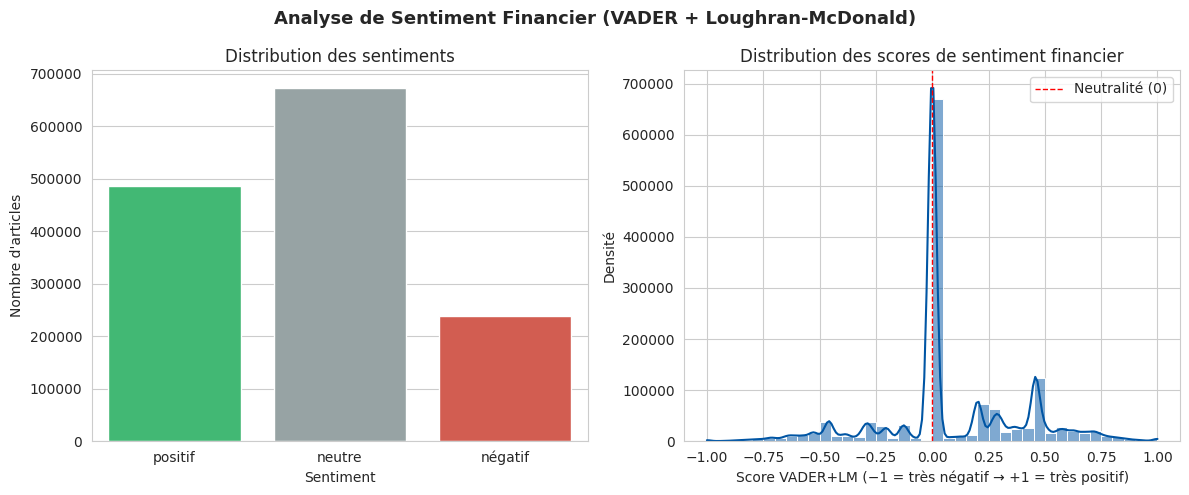

💾 Graphique sauvegardé → figures/sentiment_distribution.png


In [7]:
## 5. Scoring du sentiment avec VADER augmenté du Lexique Loughran-McDonald (LM)
# ── 1. Lexique Loughran-McDonald (LM) ──────────────────────────────────────
# Mots financiers positifs (sous-valorisés par VADER)
LM_POSITIVE = [
    "profit", "profitable", "profitability", "revenue", "growth", "beat", "exceeded",
    "outperform", "upgrade", "upside", "bullish", "momentum", "strong", "strengthens",
    "record", "soar", "rally", "surge", "boost", "dividend", "buyback", "acquisition",
    "robust", "breakthrough", "innovative", "expansion", "gain", "recovery", "rebound",
    "overweight", "optimistic", "confident", "accelerating", "improving", "efficient",
    "leading", "dominant", "milestone", "delivers", "exceed", "outpaces", "favorable",
    "solid", "healthy", "resilient", "advantage", "raised", "lifted", "upgraded",
]

# Mots financiers négatifs (sous-valorisés ou mal classifiés par VADER)
LM_NEGATIVE = [
    "loss", "losses", "deficit", "bankruptcy", "default", "downgrade", "miss",
    "missed", "shortfall", "warning", "volatile", "volatility", "risk", "risks",
    "liability", "liabilities", "debt", "fraud", "investigation", "lawsuit",
    "decline", "declining", "downturn", "recession", "layoffs", "restructuring",
    "impairment", "writedown", "write-off", "restatement", "bearish", "underperform",
    "downside", "slump", "plunge", "slash", "weak", "weakening", "disappointing",
    "underweight", "concern", "uncertainty", "headwind", "challenging", "struggling",
    "suspended", "halted", "penalty", "fine", "recall", "breach", "probe", "subpoena",
    "dilution", "dilutive", "squeeze", "crisis", "contagion", "exposure", "cut",
]

# Mots ambigus que VADER sur-interprète → on les ramène à la neutralité
LM_NEUTRAL_OVERRIDE = [
    "market", "stock", "share", "shares", "option", "merger",
    "interest", "rate", "capital", "fund", "quarter", "annual", "fiscal",
    "earnings", "price", "volume", "position", "holding", "stake",
]

# ── 2. Phrases contextuelles financières (bonus/malus) ─────────────────────
CONTEXT_PHRASES = {
    "earnings beat":           +2.5,
    "earnings miss":           -2.5,
    "record earnings":         +2.0,
    "record revenue":          +2.0,
    "record profit":           +2.0,
    "beats estimates":         +2.0,
    "misses estimates":        -2.0,
    "beats expectations":      +2.0,
    "misses expectations":     -2.0,
    "profit warning":          -2.5,
    "guidance cut":            -2.5,
    "raised guidance":         +2.0,
    "lowered guidance":        -2.0,
    "dividend cut":            -2.0,
    "dividend increase":       +1.8,
    "dividend hike":           +1.8,
    "stock buyback":           +1.5,
    "share repurchase":        +1.5,
    "chapter 11":              -3.5,
    "going concern":           -3.0,
    "accounting fraud":        -3.5,
    "sec investigation":       -2.5,
    "class action":            -2.0,
    "credit downgrade":        -2.5,
    "credit upgrade":          +2.0,
    "cash flow positive":      +2.5,
    "debt restructuring":      -1.5,
    "ipo":                     +1.0,
    "initial public offering": +1.0,
}

# ── 3. Injection du lexique financier dans VADER ────────────────────────────
analyzer = SentimentIntensityAnalyzer()

FINANCE_LEXICON = {}
for word in LM_POSITIVE:
    FINANCE_LEXICON[word] = 2.0   # sur l'échelle VADER [-4, +4]
for word in LM_NEGATIVE:
    FINANCE_LEXICON[word] = -2.0
for word in LM_NEUTRAL_OVERRIDE:
    FINANCE_LEXICON[word] = 0.0   # écrase les biais VADER

analyzer.lexicon.update(FINANCE_LEXICON)

# ── 4. Fonction de scoring financier ────────────────────────────────────────
def financial_vader_compound(text: str) -> float:
    """
    Score de sentiment financier VADER+LM :
      - VADER enrichi du lexique Loughran-McDonald (correction terminologie finance)
      - Bonus/malus sur phrases contextuelles financières connues
    Score final clampé dans [−1, +1].
    """
    if not text:
        return 0.0

    lower = text.lower()

    # Score de base VADER (avec lexique LM déjà intégré)
    base_score = analyzer.polarity_scores(text)["compound"]

    # Ajustement par phrases contextuelles
    phrase_adjustment = 0.0
    n_triggers = 0
    for phrase, adj in CONTEXT_PHRASES.items():
        if phrase in lower:
            phrase_adjustment += adj
            n_triggers += 1

    # Normalisation si plusieurs phrases trouvées (pondération modérée)
    if n_triggers > 0:
        phrase_adjustment = (phrase_adjustment / n_triggers) * 0.3

    return float(max(-1.0, min(1.0, base_score + phrase_adjustment)))

# ── 5. Validation sur cas de test typiques ──────────────────────────────────
test_cases = [
    ("Company reports record earnings, beats estimates by 15%",      "positif attendu"),
    ("Firm files for Chapter 11 bankruptcy amid fraud investigation", "négatif attendu"),
    ("CEO issues profit warning, guidance cut for Q3",               "négatif attendu"),
    ("Strong revenue growth driven by new product launches",         "positif attendu"),
    ("SEC investigation reveals accounting fraud, shares plunge 40%","négatif attendu"),
    ("Dividend increase announced alongside share buyback program",  "positif attendu"),
    ("Company faces rising liabilities and growing debt pile",       "négatif attendu"),
]

print("=== Validation du scoring VADER+LM (vs. VADER seul) ===\n")
print(f"{'Cas de test':<55} {'VADER+LM':>9}  {'Label':>8}  {'Attendu'}")
print("-" * 90)
vader_only = SentimentIntensityAnalyzer()   # VADER non augmenté pour comparaison
for headline, expected in test_cases:
    score_lm   = financial_vader_compound(headline)
    score_base = vader_only.polarity_scores(headline)["compound"]
    label = "positif" if score_lm >= 0.05 else ("négatif" if score_lm <= -0.05 else "neutre")
    ok    = "✅" if expected.startswith(label) else "⚠️"
    delta = score_lm - score_base
    print(f"{ok} {headline[:53]:<53} {score_lm:+.3f}  ({delta:+.3f})  {label:>8}  {expected}")

print("\n⏳ Calcul des scores financiers sur l'ensemble du dataset...")

df_news = df_news.with_columns(
    pl.col("headline")
    .map_elements(financial_vader_compound, return_dtype=pl.Float64)
    .alias("sentiment_score")
)

# Catégorisation
df_news = df_news.with_columns(
    pl.when(pl.col("sentiment_score") >= 0.05).then(pl.lit("positif"))
    .when(pl.col("sentiment_score") <= -0.05).then(pl.lit("négatif"))
    .otherwise(pl.lit("neutre"))
    .alias("sentiment_label")
)

print(f"✅ Scores financiers VADER+LM calculés pour {df_news.shape[0]:,} articles.\n")
print("Répartition des sentiments :")
display(df_news["sentiment_label"].value_counts().to_pandas())
display(df_news.head(5).to_pandas())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Analyse de Sentiment Financier (VADER + Loughran-McDonald)", fontsize=13, fontweight='bold')

sns.countplot(data=df_news.to_pandas(), x="sentiment_label",
              order=["positif", "neutre", "négatif"], ax=axes[0],
              palette={"positif": "#2ecc71", "neutre": "#95a5a6", "négatif": "#e74c3c"})
axes[0].set_title("Distribution des sentiments")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Nombre d'articles")

sns.histplot(data=df_news.to_pandas(), x="sentiment_score", bins=40, kde=True,
             ax=axes[1], color="#0055A4")
axes[1].axvline(0, color='red', linestyle='--', linewidth=1, label='Neutralité (0)')
axes[1].set_title("Distribution des scores de sentiment financier")
axes[1].set_xlabel("Score VADER+LM (−1 = très négatif → +1 = très positif)")
axes[1].set_ylabel("Densité")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/sentiment_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("💾 Graphique sauvegardé → figures/sentiment_distribution.png")
df_news.write_parquet("data/processed/news_with_sentiment.parquet")


## 5. Agrégation du Sentiment par Jour et par Ticker

Pour chaque paire *(date, ticker)*, on agrège les scores individuels des articles en 6 indicateurs :
somme cumulée, moyenne, écart-type, nombre d'articles, part positive et part négative.

In [8]:
## 6. Agrégation du sentiment par jour et par action

daily_sentiment = (
    df_news
    .group_by(["date_only", "ticker"])
    .agg([
        pl.col("sentiment_score").sum().alias("sentiment_sum"),
        pl.col("sentiment_score").mean().alias("sentiment_mean"),
        pl.col("sentiment_score").std().alias("sentiment_std"),
        pl.col("sentiment_score").count().alias("n_articles"),
        (pl.col("sentiment_label") == "positif").mean().alias("pct_positif"),
        (pl.col("sentiment_label") == "négatif").mean().alias("pct_negatif"),
    ])
    .sort(["ticker", "date_only"])
)

print(f"✅ Sentiment agrégé : {daily_sentiment.shape[0]:,} (date × ticker) uniques")
display(daily_sentiment.head(10).to_pandas())

✅ Sentiment agrégé : 836,646 (date × ticker) uniques


,date_only,ticker,sentiment_sum,sentiment_mean,sentiment_std,n_articles,pct_positif,pct_negatif
0,2009-04-29,A,0.0000,0.000000,NaN,1,0.000000,0.000000
1,2009-06-01,A,0.2960,0.296000,NaN,1,1.000000,0.000000
2,2009-07-14,A,0.7184,0.718400,NaN,1,1.000000,0.000000
3,2009-07-30,A,0.0000,0.000000,NaN,1,0.000000,0.000000
4,2009-08-04,A,0.0000,0.000000,NaN,1,0.000000,0.000000
5,2009-08-06,A,-0.3403,-0.068060,0.594147,5,0.200000,0.200000
6,2009-08-07,A,12.8796,0.157068,0.339197,82,0.402439,0.073171
7,2009-08-08,A,-1.0000,-1.000000,NaN,1,0.000000,1.000000
8,2009-08-09,A,1.8877,0.377540,0.463877,5,0.600000,0.200000
9,2009-08-10,A,23.1694,0.150451,0.313043,154,0.396104,0.051948


## 6. Extraction des Données Boursières (Yahoo Finance)

Téléchargement des prix de clôture journaliers pour les **1 000 tickers les plus couverts** via l'API `yfinance`, sur la période 2009–2020.

In [32]:
## 6. Extraction des données boursières (Yahoo Finance) — TOUS les tickers

# ── Tous les tickers présents dans daily_sentiment ─────────────────────────
all_tickers = (
    daily_sentiment
    .group_by("ticker")
    .agg(pl.col("n_articles").sum().alias("total_articles"))
    .sort("total_articles", descending=True)
    ["ticker"]
    .to_list()
)

START_DATE = daily_sentiment['date_only'].min().strftime('%Y-%m-%d')
END_DATE   = daily_sentiment['date_only'].max().strftime('%Y-%m-%d')
!rm -r data/processed/stock_prices.parquet  # IGNORE - forcer le re-téléchargement pendant les tests

print(f"📅 Période        : {START_DATE} → {END_DATE}")
print(f"📈 Tickers total  : {len(all_tickers):,}")
print(f"📈 Top 10 tickers : {all_tickers[:10]}")

# ── Téléchargement par lots de 200 (robustesse yfinance) ──────────────────
BATCH_SIZE   = 500
prices_cache = "data/processed/stock_prices.parquet"

if os.path.exists(prices_cache):
    print(f"\n⏭️  Prix déjà en cache → chargement depuis {prices_cache}")
    df_prices = pl.read_parquet(prices_cache)
else:
    batches  = [all_tickers[i:i+BATCH_SIZE] for i in range(0, len(all_tickers), BATCH_SIZE)]
    dfs_list = []
    n_ok, n_fail = 0, 0

    for idx, batch in enumerate(batches):
        try:
            raw = yf.download(
                batch,
                start=START_DATE,
                end=END_DATE,
                auto_adjust=True,
                progress=True,
                threads=True,
            )
            if raw.empty:
                n_fail += len(batch)
                continue

            # Gérer le cas d'un seul ticker (yfinance renvoie un format plat)
            if isinstance(raw.columns, pd.MultiIndex):
                close_col = raw["Close"]
            else:
                close_col = raw[["Close"]].rename(columns={"Close": batch[0]})

            df_batch = (
                pl.from_pandas(close_col.reset_index())
                .unpivot(index="Date", variable_name="ticker", value_name="close_price")
                .with_columns([
                    pl.col("ticker").str.to_uppercase().str.strip_chars(),
                    pl.col("Date").cast(pl.Date).alias("date_only"),
                ])
                .select(["date_only", "ticker", "close_price"])
                .drop_nulls(subset=["close_price"])
            )
            dfs_list.append(df_batch)
            n_ok += df_batch["ticker"].n_unique()
        except Exception as e:
            n_fail += len(batch)
            print(f"  ⚠️  Lot {idx+1}/{len(batches)} — erreur : {e}")

        if (idx + 1) % 5 == 0 or idx == len(batches) - 1:
            print(f"  ✅ Lot {idx+1}/{len(batches)} traité  |  tickers récupérés ≈ {n_ok:,}")

    df_prices = pl.concat(dfs_list)
    df_prices.write_parquet(prices_cache)
    print(f"\n⚠️  Tickers sans prix : ~{n_fail}")

print(f"\n✅ Prix disponibles : {df_prices.shape[0]:,} lignes")
print(f"   Tickers couverts : {df_prices['ticker'].n_unique():,}")
display(df_prices.head(5).to_pandas())

📅 Période        : 2009-02-14 → 2020-06-11
📈 Tickers total  : 6,192
📈 Top 10 tickers : ['MRK', 'MS', 'MU', 'NVDA', 'QQQ', 'M', 'EBAY', 'NFLX', 'GILD', 'VZ']


[*********************100%***********************]  500 of 500 completed
ERROR:yfinance:
145 Failed downloads:
ERROR:yfinance:['ACHN', 'KSU', 'FCAU', 'CTXS', 'DGLY', 'IMMU', 'FRED', 'TIVO', 'FTR', 'CHK', 'FEYE', 'TPX', 'PIR', 'VMW', 'CHS', 'MDCO', 'NBL', 'CS', 'LL', 'CLVS', 'DISH', 'DRYS', 'RHT', 'AKRX', 'AVP', 'MXIM', 'HZNP', 'BKS', 'ZNGA', 'MYL', 'CREE', 'FNSR', 'GNC', 'SPLK', 'ATVI', 'BIG', 'DNKN', 'PXD', 'ABC', 'ECA', 'WFT', 'ENDP', 'YHOO', 'IRBT', 'SGEN', 'JASO', 'GPS', 'CY', 'HRS', 'ALTR', 'CEO', 'AKS', 'ANTM', 'GCI', 'FL', 'TIF', 'GLUU', 'ACOR', 'OCN', 'ADS', 'ODP', 'X', 'MON', 'GRUB', 'SAVE', 'RAD', 'ARNA', 'DO', 'ASNA', 'ICPT', 'DF', 'K', 'JWN', 'CLR', 'ATHN', 'MRO', 'NUAN', 'WBA', 'WLL', 'SWN', 'ETFC', 'JNPR', 'MLNX', 'VVUS', 'SKX', 'NLNK', 'JCP', 'BLUE', 'RBS', 'DTV', 'DFS', 'IGT', 'CTL', 'JEC', 'AGN', 'OSTK', 'SYMC', 'GWPH', 'DISCA', 'NAV', 'SINA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['SNDK', 'SPWR', 'NE', 'ABX', 'STI', 'TOT', 'TSL', 'CA

  ✅ Lot 10/13 traité  |  tickers récupérés ≈ 879


[*********************100%***********************]  500 of 500 completed
ERROR:yfinance:
494 Failed downloads:
ERROR:yfinance:['VGGL', 'AMCO', 'HDGE', 'NML', 'MEIL', 'CXE', 'EEA', 'CIK', 'MDD', 'ENY', 'JEQ', 'NEN', 'MIW', 'ERC', 'AAXJ', 'ACWV', 'SLVP', 'DMB', 'APEI', 'DMF', 'GOODP', 'IAF', 'SVLC', 'DNP', 'EDD', 'BPOPN', 'BAF', 'BDCV', 'VIIX', 'DGRS', 'MLN', 'WITE', 'LMCB', 'LABC', 'CBIN', 'TYO', 'MHD', 'CIF', 'INTG', 'BME', 'MSF', 'DJP', 'GDL', 'HNW', 'FNFV', 'HTD', 'GLU', 'FEO', 'ACWI', 'AZIA', 'MHE', 'BLH', 'HYMB', 'PXH', 'CGW', 'BBRC', 'BABS', 'VKQ', 'EDF', 'MOAT', 'VTIP', 'XLG', 'FIF', 'BIL', 'DBMX', 'ISRA', 'VVR', 'SCHP', 'WHZ', 'TLTE', 'FCHI', 'UPV', 'PSBH', 'WDTI', 'ARKK', 'UGLD', 'PFXF', 'CHSCO', 'EMQQ', 'GLQ', 'SRS', 'AFCB', 'VOT', 'NECB', 'PMM', 'SBIO', 'DBP', 'MFM', 'BQH', 'ANCB', 'BKN', 'PIM', 'BA', 'ASHS', 'NKY', 'PXJ', 'SAR', 'UTG', 'MAV', 'BSE', 'MDIV', 'QQEW', 'BPK', 'RGT', 'BKEPP', 'DBGR', 'INTC', 'BTA', 'GURU', 'FXR', 'BGCA', 'NRCIB', 'DXPS', 'RYH', 'KBWP', 'BAR', 'AL

  ✅ Lot 13/13 traité  |  tickers récupérés ≈ 901

⚠️  Tickers sans prix : ~1500

✅ Prix disponibles : 2,383,727 lignes
   Tickers couverts : 901


,date_only,ticker,close_price
0,2009-02-17,A,11.196862
1,2009-02-18,A,10.181851
2,2009-02-19,A,9.871000
3,2009-02-20,A,9.629935
4,2009-02-23,A,9.058988


## 7. Calcul des Rendements Logarithmiques

Construction de la variable cible : $r_{i,t} = \ln(P_{i,t} / P_{i,t-1})$.  
Fusion (*inner join*) avec les données de sentiment → jeu de données de panel **844 entreprises × 2009–2020**.

In [34]:
## 8. Calcul de la volatilité (log-rendements + fenêtre mobile 5 jours)
df_final = (
    df_prices
    .sort(["ticker", "date_only"])
    .with_columns([
        (pl.col("close_price") / pl.col("close_price").shift(1)).log().alias("log_return")
    ])
    .with_columns([
        pl.col("log_return").fill_null(strategy="forward")
        .fill_null(0.0)
    ])
)
df_final = (
    daily_sentiment
    .join(df_final, on=["date_only", "ticker"], how="inner")
)
df_final

date_only,ticker,sentiment_sum,sentiment_mean,sentiment_std,n_articles,pct_positif,pct_negatif,close_price,log_return
date,str,f64,f64,f64,u32,f64,f64,f64,f64
2009-04-29,"""A""",0.0,0.0,null,1,0.0,0.0,11.437925,0.056474
2009-06-01,"""A""",0.296,0.296,null,1,1.0,0.0,11.977155,0.035034
2009-07-14,"""A""",0.7184,0.7184,null,1,1.0,0.0,12.364129,0.005144
2009-07-30,"""A""",0.0,0.0,null,1,0.0,0.0,14.692307,0.02315
2009-08-04,"""A""",0.0,0.0,null,1,0.0,0.0,15.333038,0.009144
…,…,…,…,…,…,…,…,…,…
2020-04-13,"""ZUMZ""",-0.6908,-0.6908,null,1,0.0,1.0,21.23,-0.030158
2020-05-21,"""ZUMZ""",0.2732,0.2732,null,1,1.0,0.0,21.84,0.088011
2020-05-27,"""ZUMZ""",0.4588,0.4588,null,1,1.0,0.0,25.299999,0.080207


## 8. Analyse Descriptive du Jeu de Données Fusionné

Visualisation des distributions du sentiment et des rendements, et nuage de points global sentiment vs rendement. La corrélation globale (+0.144) confirme l'existence d'un signal exploitable.

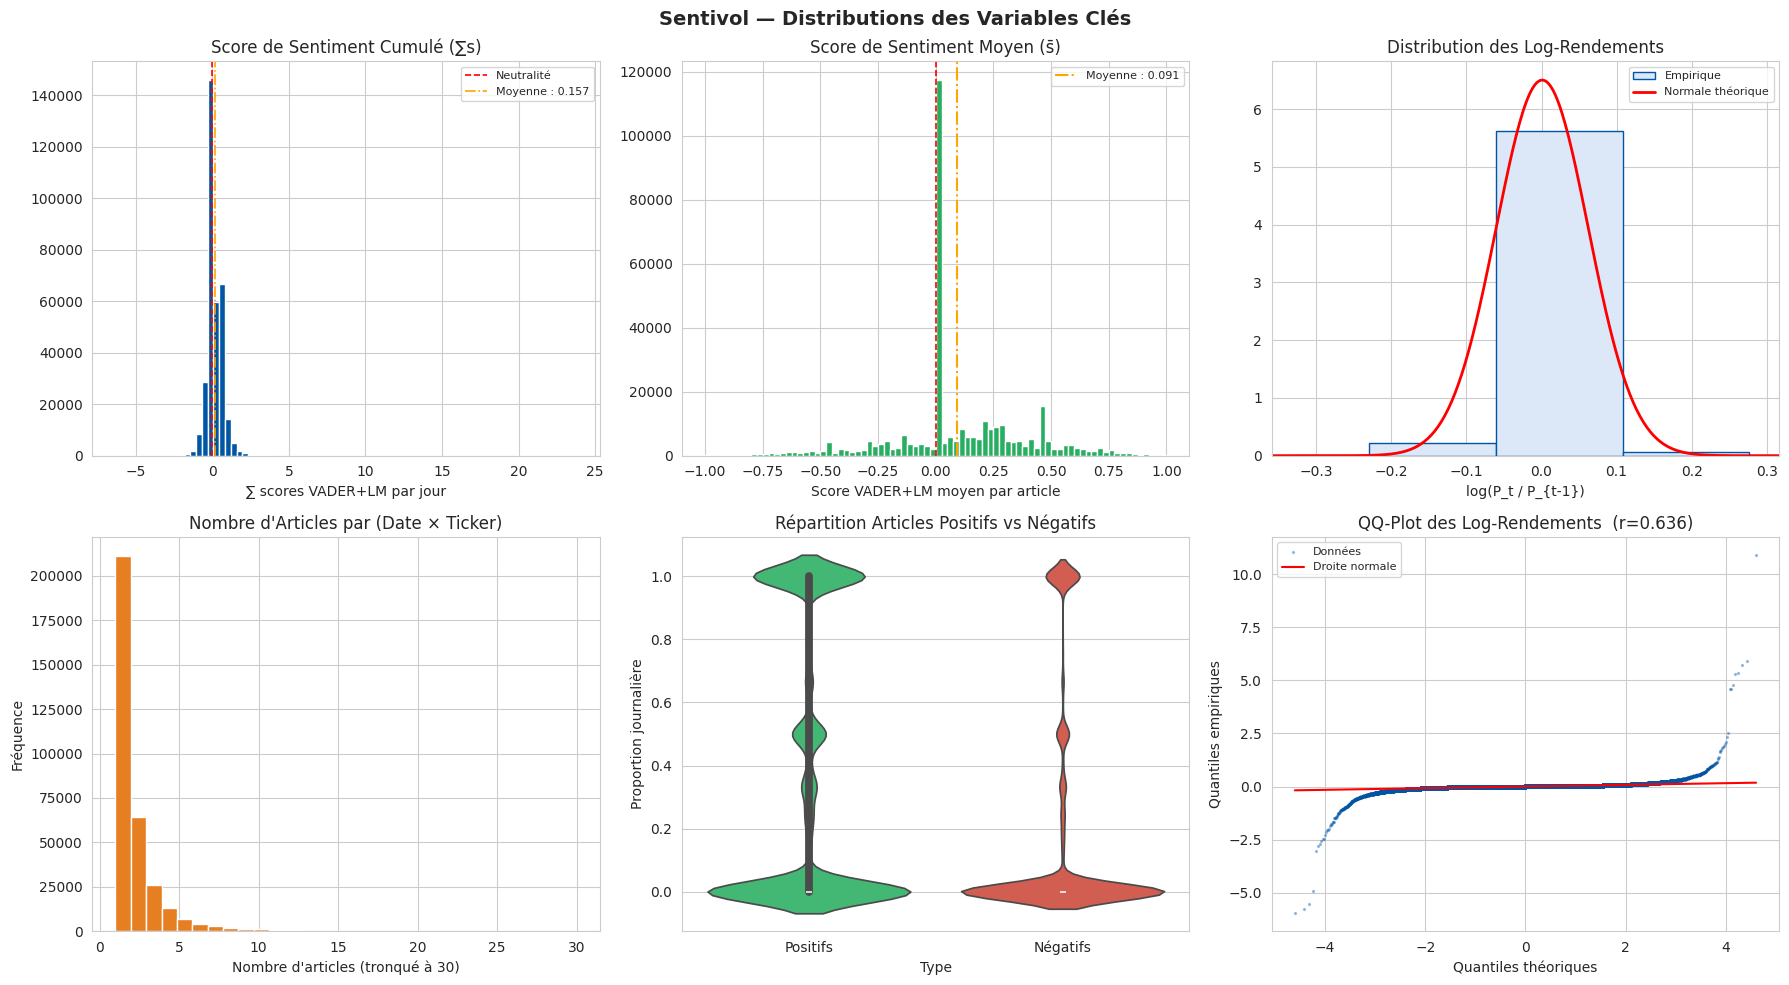

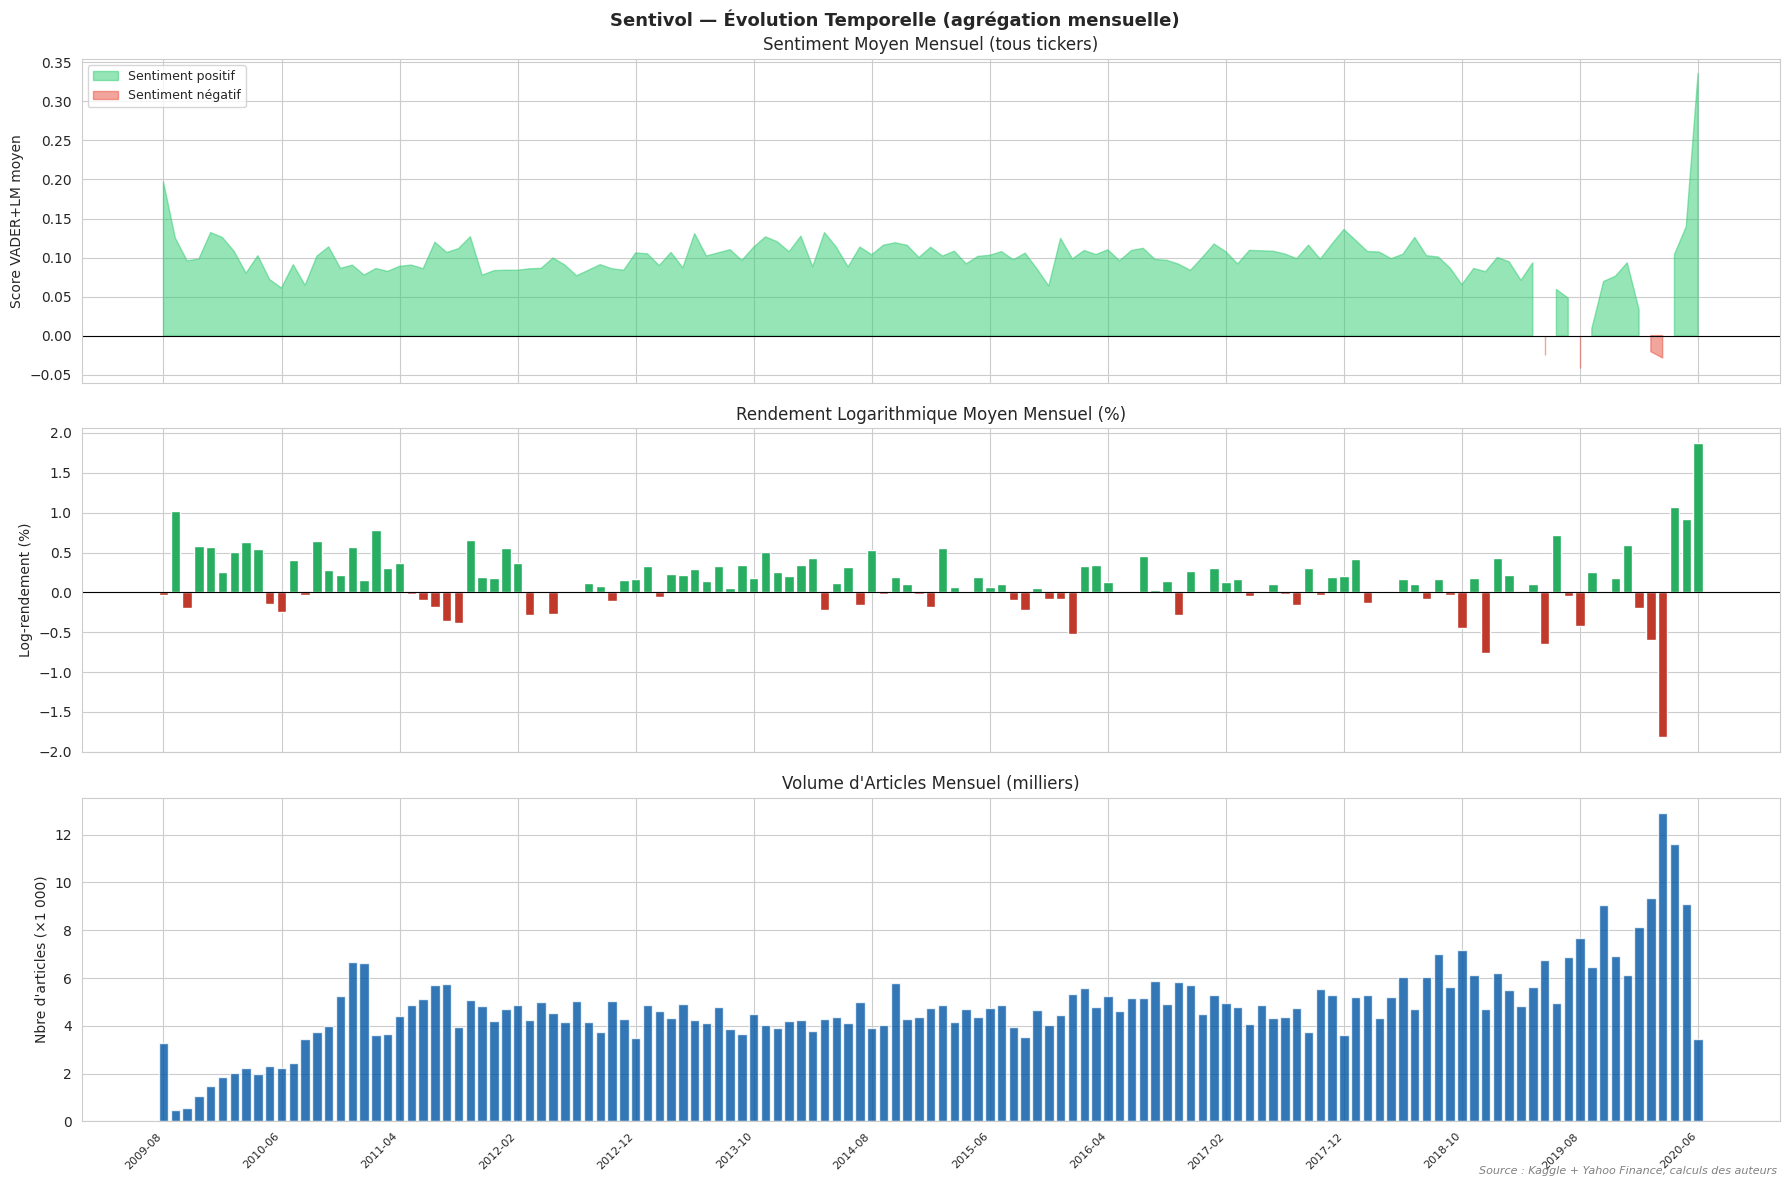

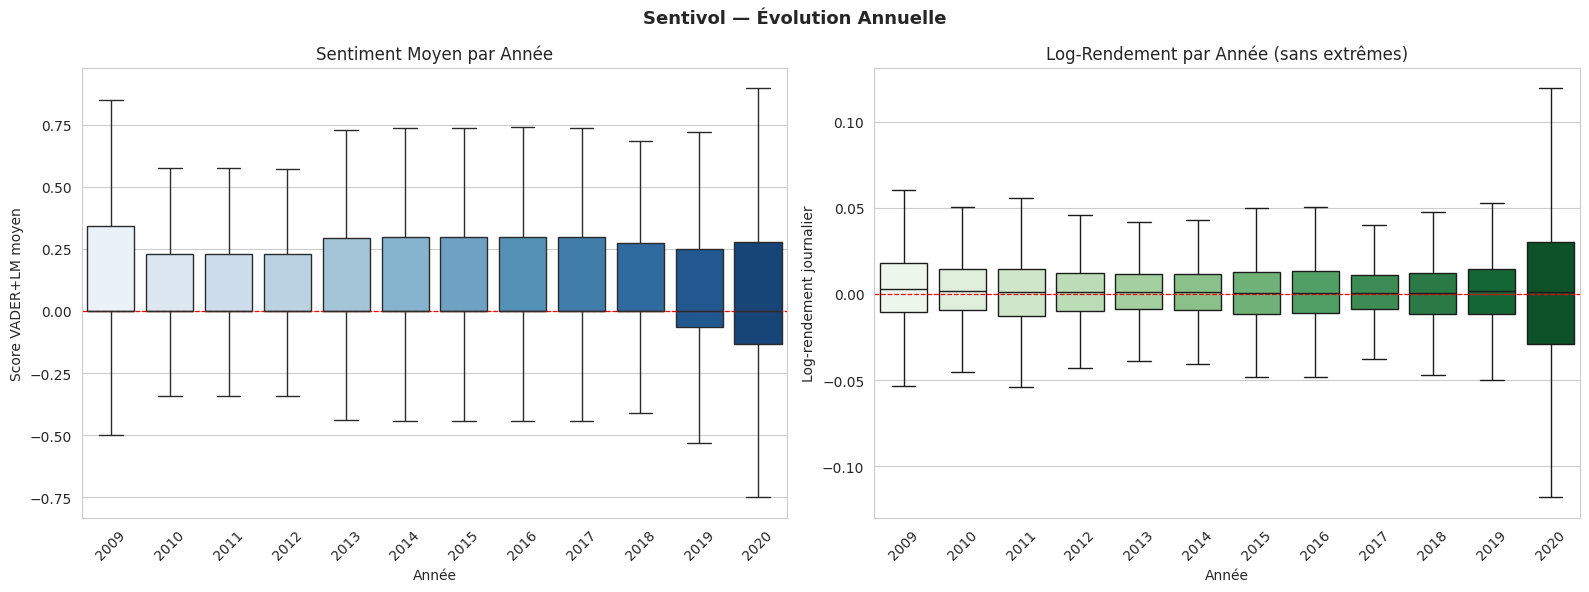

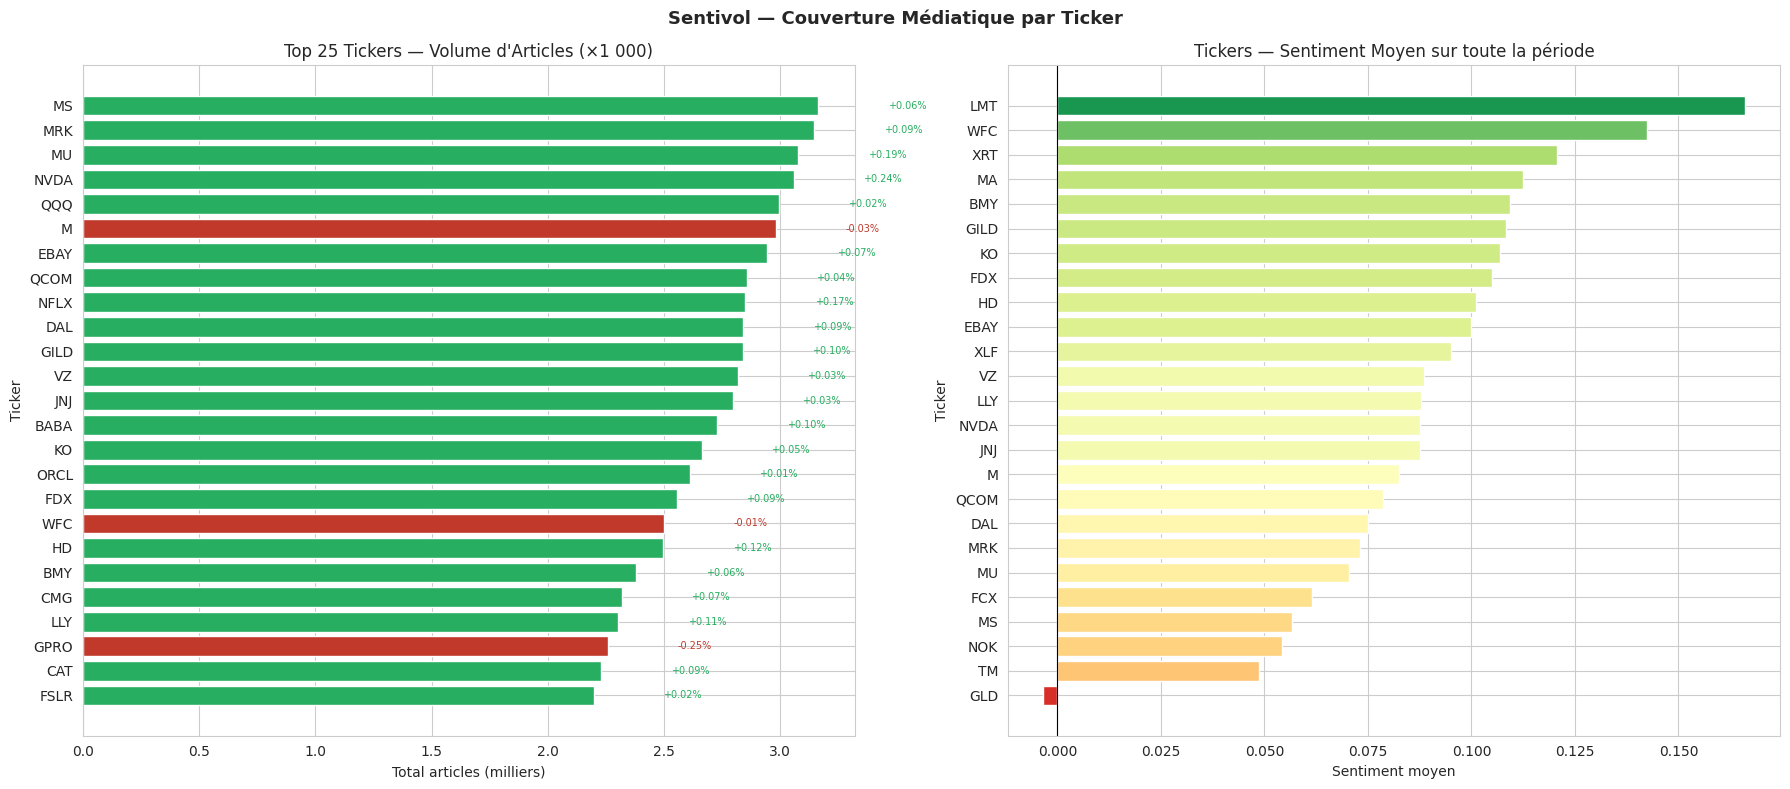

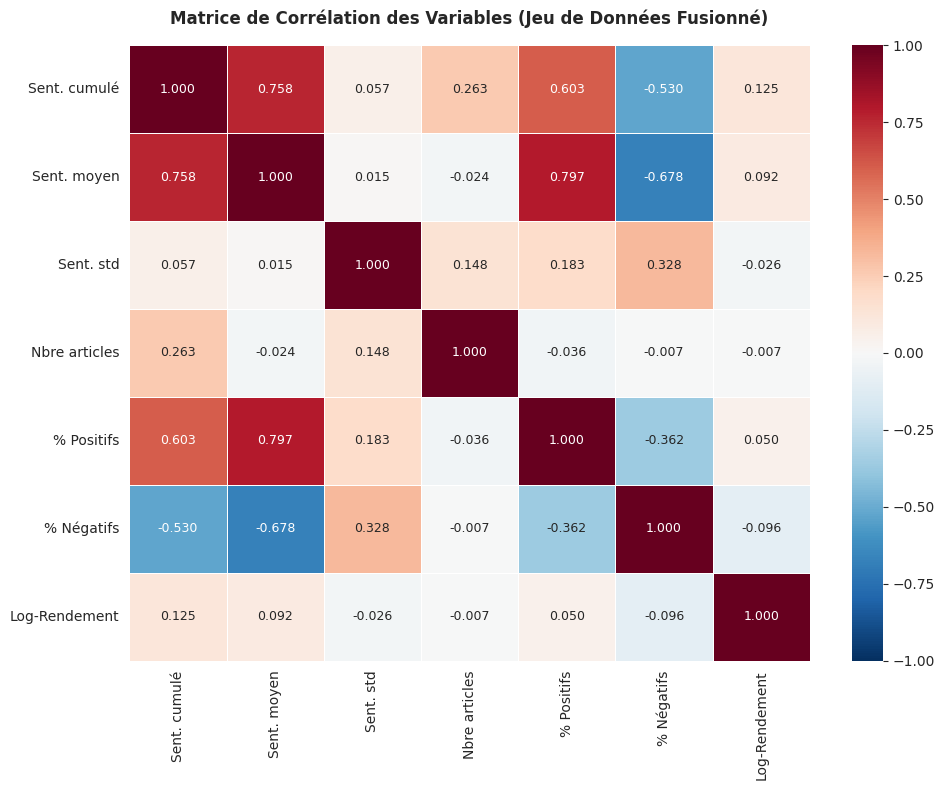


📊 STATISTIQUES GLOBALES DU JEU DE DONNÉES FUSIONNÉ
  Observations totales     :      335,781
  Tickers uniques          :          895
  Jours couverts           :        2,749
  Observations / ticker    :          375 (moy.)
  Sentiment cumulé (moy.)  :      +0.1573
  Log-rendement (moy.)     :    +0.000947
  Corrél. globale ∑s / r   :      +0.1245
  Corrél. globale s̄  / r   :      +0.0922

✅ Graphiques sauvegardés :
   → figures/descriptive_distributions.png
   → figures/descriptive_time_series.png
   → figures/descriptive_annual_boxplots.png
   → figures/descriptive_ticker_coverage.png
   → figures/descriptive_correlation_matrix.png


In [35]:
## 8. Analyse Descriptive — Dashboard complet

df_plot = df_final.to_pandas()
df_plot["year"]  = pd.to_datetime(df_plot["date_only"].astype(str)).dt.year
df_plot["month"] = pd.to_datetime(df_plot["date_only"].astype(str)).dt.to_period("M").astype(str)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Figure 1 — Distributions des variables clés
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig1, axes = plt.subplots(2, 3, figsize=(18, 10))
fig1.suptitle("Sentivol — Distributions des Variables Clés", fontsize=14, fontweight="bold")

# (1) Distribution du sentiment cumulé
axes[0,0].hist(df_plot["sentiment_sum"], bins=80, color="#0055A4", edgecolor="white")
axes[0,0].axvline(0, color="red", linestyle="--", linewidth=1.2, label="Neutralité")
axes[0,0].axvline(df_plot["sentiment_sum"].mean(), color="orange", linestyle="-.", linewidth=1.2,
                  label=f"Moyenne : {df_plot['sentiment_sum'].mean():.3f}")
axes[0,0].set_title("Score de Sentiment Cumulé (∑s)")
axes[0,0].set_xlabel("∑ scores VADER+LM par jour")
axes[0,0].legend(fontsize=8)

# (2) Distribution du sentiment moyen
axes[0,1].hist(df_plot["sentiment_mean"], bins=80, color="#27ae60", edgecolor="white")
axes[0,1].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[0,1].axvline(df_plot["sentiment_mean"].mean(), color="orange", linestyle="-.",
                  label=f"Moyenne : {df_plot['sentiment_mean'].mean():.3f}")
axes[0,1].set_title("Score de Sentiment Moyen (s̄)")
axes[0,1].set_xlabel("Score VADER+LM moyen par article")
axes[0,1].legend(fontsize=8)

# (3) Distribution des log-rendements avec courbe normale
from scipy import stats as scipy_stats
lr_clean = df_plot["log_return"].dropna()
axes[0,2].hist(lr_clean, bins=100, color="#DCE7F7", edgecolor="#0055A4",
               density=True, label="Empirique")
xmin, xmax = lr_clean.quantile(0.001), lr_clean.quantile(0.999)
x_norm = np.linspace(xmin, xmax, 300)
axes[0,2].plot(x_norm, scipy_stats.norm.pdf(x_norm, lr_clean.mean(), lr_clean.std()),
               "r-", linewidth=2, label="Normale théorique")
axes[0,2].set_xlim(xmin, xmax)
axes[0,2].set_title("Distribution des Log-Rendements")
axes[0,2].set_xlabel("log(P_t / P_{t-1})")
axes[0,2].legend(fontsize=8)

# (4) Distribution du nombre d'articles par observation
axes[1,0].hist(df_plot["n_articles"].clip(upper=30), bins=30, color="#e67e22", edgecolor="white")
axes[1,0].set_title("Nombre d'Articles par (Date × Ticker)")
axes[1,0].set_xlabel("Nombre d'articles (tronqué à 30)")
axes[1,0].set_ylabel("Fréquence")

# (5) Distribution des % articles positifs vs négatifs (violon)
df_melt = df_plot[["pct_positif", "pct_negatif"]].melt(var_name="Type", value_name="Proportion")
df_melt["Type"] = df_melt["Type"].map({"pct_positif": "Positifs", "pct_negatif": "Négatifs"})
sns.violinplot(data=df_melt, x="Type", y="Proportion",
               palette={"Positifs": "#2ecc71", "Négatifs": "#e74c3c"}, ax=axes[1,1])
axes[1,1].set_title("Répartition Articles Positifs vs Négatifs")
axes[1,1].set_ylabel("Proportion journalière")

# (6) QQ-Plot des log-rendements
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(lr_clean, dist="norm")
axes[1,2].scatter(osm, osr, s=2, alpha=0.3, color="#0055A4", label="Données")
axes[1,2].plot(osm, slope * np.array(osm) + intercept, "r-", linewidth=1.5, label="Droite normale")
axes[1,2].set_title(f"QQ-Plot des Log-Rendements  (r={r:.3f})")
axes[1,2].set_xlabel("Quantiles théoriques")
axes[1,2].set_ylabel("Quantiles empiriques")
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/descriptive_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Figure 2 — Évolution temporelle
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
monthly_ts = (
    df_plot.groupby("month", sort=True)
    .agg(
        sentiment_mean=("sentiment_mean", "mean"),
        log_return_mean=("log_return", "mean"),
        n_articles_total=("n_articles", "sum"),
        n_obs=("log_return", "count"),
    )
    .reset_index()
)
monthly_ts = monthly_ts[monthly_ts["n_obs"] > 50]   # filtre mois peu peuplés

fig2, axes2 = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
fig2.suptitle("Sentivol — Évolution Temporelle (agrégation mensuelle)", fontsize=13, fontweight="bold")

# (a) Sentiment moyen mensuel
axes2[0].fill_between(range(len(monthly_ts)), monthly_ts["sentiment_mean"],
                      where=monthly_ts["sentiment_mean"] >= 0,
                      color="#2ecc71", alpha=0.5, label="Sentiment positif")
axes2[0].fill_between(range(len(monthly_ts)), monthly_ts["sentiment_mean"],
                      where=monthly_ts["sentiment_mean"] < 0,
                      color="#e74c3c", alpha=0.5, label="Sentiment négatif")
axes2[0].axhline(0, color="black", linewidth=0.8)
axes2[0].set_title("Sentiment Moyen Mensuel (tous tickers)")
axes2[0].set_ylabel("Score VADER+LM moyen")
axes2[0].legend(fontsize=9)

# (b) Rendement moyen mensuel
axes2[1].bar(range(len(monthly_ts)), monthly_ts["log_return_mean"] * 100,
             color=["#27ae60" if v >= 0 else "#c0392b" for v in monthly_ts["log_return_mean"]])
axes2[1].axhline(0, color="black", linewidth=0.8)
axes2[1].set_title("Rendement Logarithmique Moyen Mensuel (%)")
axes2[1].set_ylabel("Log-rendement (%)")

# (c) Volume d'articles mensuel
axes2[2].bar(range(len(monthly_ts)), monthly_ts["n_articles_total"] / 1000,
             color="#0055A4", alpha=0.8)
axes2[2].set_title("Volume d'Articles Mensuel (milliers)")
axes2[2].set_ylabel("Nbre d'articles (×1 000)")

# Labels de l'axe X : afficher une étiquette tous les 12 mois
step  = max(1, len(monthly_ts) // 12)
xtick = range(0, len(monthly_ts), step)
axes2[2].set_xticks(list(xtick))
axes2[2].set_xticklabels(
    [monthly_ts["month"].iloc[i] for i in xtick], rotation=45, ha="right", fontsize=8
)

plt.figtext(0.99, 0.01, "Source : Kaggle + Yahoo Finance, calculs des auteurs",
            ha="right", fontsize=8, style="italic", color="gray")
plt.tight_layout()
plt.savefig("figures/descriptive_time_series.png", dpi=150, bbox_inches="tight")
plt.show()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Figure 3 — Analyse annuelle par boîtes à moustaches
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle("Sentivol — Évolution Annuelle", fontsize=13, fontweight="bold")

sns.boxplot(data=df_plot, x="year", y="sentiment_mean", ax=axes3[0],
            palette="Blues", showfliers=False)
axes3[0].axhline(0, color="red", linestyle="--", linewidth=0.9)
axes3[0].set_title("Sentiment Moyen par Année")
axes3[0].set_xlabel("Année")
axes3[0].set_ylabel("Score VADER+LM moyen")
axes3[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df_plot[df_plot["log_return"].between(-0.15, 0.15)],
            x="year", y="log_return", ax=axes3[1], palette="Greens", showfliers=False)
axes3[1].axhline(0, color="red", linestyle="--", linewidth=0.9)
axes3[1].set_title("Log-Rendement par Année (sans extrêmes)")
axes3[1].set_xlabel("Année")
axes3[1].set_ylabel("Log-rendement journalier")
axes3[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("figures/descriptive_annual_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Figure 4 — Top 25 / Bottom 25 tickers par volume de couverture médiatique
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ticker_coverage = (
    df_plot.groupby("ticker")
    .agg(total_articles=("n_articles", "sum"),
         avg_sentiment=("sentiment_mean", "mean"),
         avg_return=("log_return", "mean"),
         n_days=("log_return", "count"))
    .reset_index()
    .sort_values("total_articles", ascending=False)
)

fig4, axes4 = plt.subplots(1, 2, figsize=(18, 8))
fig4.suptitle("Sentivol — Couverture Médiatique par Ticker", fontsize=13, fontweight="bold")

top25 = ticker_coverage.head(25)
colors_top = ["#c0392b" if v < 0 else "#27ae60" for v in top25["avg_return"]]
bars_top = axes4[0].barh(top25["ticker"][::-1], top25["total_articles"][::-1] / 1000,
                          color=colors_top[::-1], edgecolor="white")
axes4[0].set_title("Top 25 Tickers — Volume d'Articles (×1 000)")
axes4[0].set_xlabel("Total articles (milliers)")
axes4[0].set_ylabel("Ticker")
for bar, ret in zip(bars_top, top25["avg_return"][::-1].values):
    axes4[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                  f"{ret*100:+.2f}%", va="center", fontsize=7,
                  color="#27ae60" if ret >= 0 else "#c0392b")

bot25 = ticker_coverage.nlargest(25, "n_days").sort_values("avg_sentiment")[:25]
colors_bot = [plt.cm.RdYlGn(0.1 + 0.8 * (s - bot25["avg_sentiment"].min()) /
                              (bot25["avg_sentiment"].max() - bot25["avg_sentiment"].min()))
              for s in bot25["avg_sentiment"]]
axes4[1].barh(bot25["ticker"], bot25["avg_sentiment"], color=colors_bot, edgecolor="white")
axes4[1].axvline(0, color="black", linewidth=0.8)
axes4[1].set_title("Tickers — Sentiment Moyen sur toute la période")
axes4[1].set_xlabel("Sentiment moyen")
axes4[1].set_ylabel("Ticker")

plt.tight_layout()
plt.savefig("figures/descriptive_ticker_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Figure 5 — Matrice de corrélation des features
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
feat_cols = ["sentiment_sum", "sentiment_mean", "sentiment_std",
             "n_articles", "pct_positif", "pct_negatif", "log_return"]
feat_labels = ["Sent. cumulé", "Sent. moyen", "Sent. std",
               "Nbre articles", "% Positifs", "% Négatifs", "Log-Rendement"]

corr_mat = df_plot[feat_cols].corr()
mask_tri = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)

fig5, ax5 = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_mat, mask=False, annot=True, fmt=".3f", linewidths=0.5,
            xticklabels=feat_labels, yticklabels=feat_labels,
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax5,
            annot_kws={"size": 9})
ax5.set_title("Matrice de Corrélation des Variables (Jeu de Données Fusionné)",
              fontweight="bold", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("figures/descriptive_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Résumé statistique ────────────────────────────────────────────────────
print("\n📊 STATISTIQUES GLOBALES DU JEU DE DONNÉES FUSIONNÉ")
print("=" * 65)
print(f"  Observations totales     : {len(df_plot):>12,}")
print(f"  Tickers uniques          : {df_plot['ticker'].nunique():>12,}")
print(f"  Jours couverts           : {df_plot['date_only'].nunique():>12,}")
print(f"  Observations / ticker    : {len(df_plot)/df_plot['ticker'].nunique():>12.0f} (moy.)")
print(f"  Sentiment cumulé (moy.)  : {df_plot['sentiment_sum'].mean():>+12.4f}")
print(f"  Log-rendement (moy.)     : {df_plot['log_return'].mean():>+12.6f}")
print(f"  Corrél. globale ∑s / r   : {df_plot['sentiment_sum'].corr(df_plot['log_return']):>+12.4f}")
print(f"  Corrél. globale s̄  / r   : {df_plot['sentiment_mean'].corr(df_plot['log_return']):>+12.4f}")
print("=" * 65)
print("\n✅ Graphiques sauvegardés :")
for f in ["descriptive_distributions", "descriptive_time_series",
          "descriptive_annual_boxplots", "descriptive_ticker_coverage",
          "descriptive_correlation_matrix"]:
    print(f"   → figures/{f}.png")

## 9. Corrélations Intra-Titre



Cette section mesure la relation entre le sentiment et le rendement **pour chaque ticker individuellement**.



L'objectif n'est pas de montrer une relation parfaite, mais de vérifier si le signal textuel reste orienté dans le bon sens lorsqu'on regarde les entreprises une par une. Cette étape permet aussi d'identifier les titres pour lesquels le sentiment semble plus informatif que pour d'autres.


📊 Statistiques descriptives des corrélations intra-titre :


,statistic,ticker,corr_sum,corr_mean,avg_return,total_articles,n_points
0,count,895,895.000000,895.000000,895.000000,895.000000,895.000000
1,null_count,0,0.000000,0.000000,0.000000,0.000000,0.000000
2,mean,None,NaN,NaN,0.001044,704.783240,375.174302
3,std,None,NaN,NaN,0.010840,551.545119,239.682981
4,min,A,-0.970630,-0.970630,-0.179315,1.000000,1.000000
5,25%,None,0.117004,0.088849,-0.000396,367.000000,221.000000
6,50%,None,0.196563,0.147186,0.000775,522.000000,309.000000
7,75%,None,0.270775,0.201694,0.002379,840.000000,455.000000
8,max,ZUMZ,1.000000,1.000000,0.217723,3162.000000,1449.000000


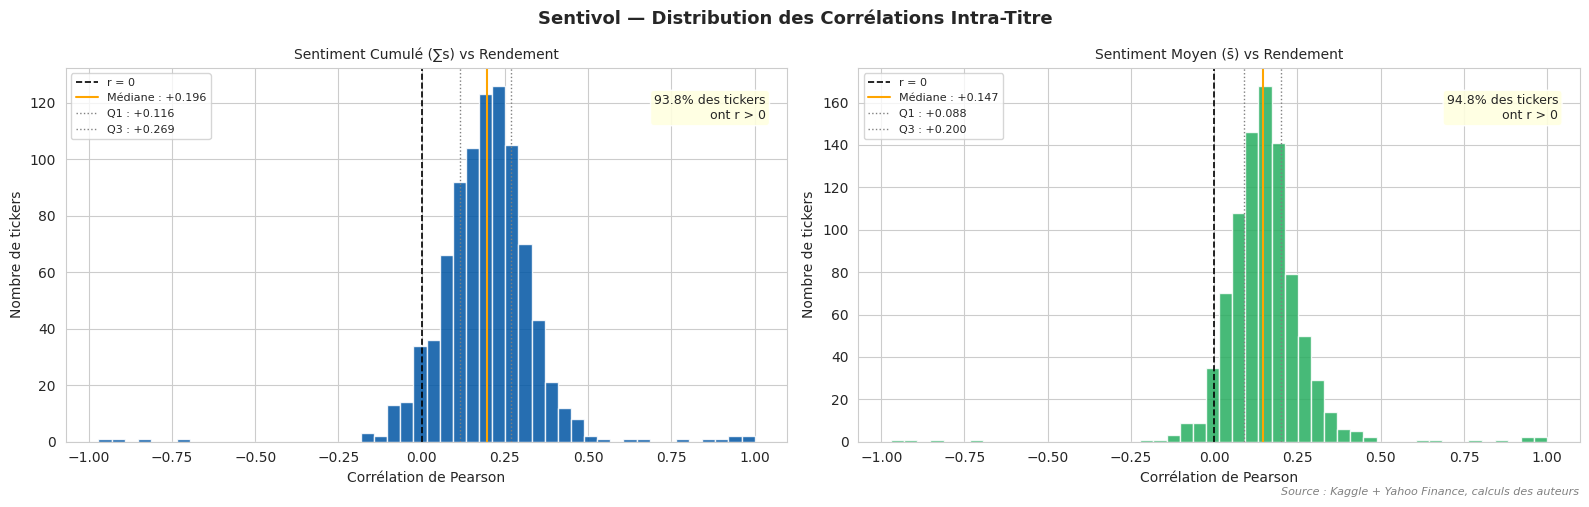

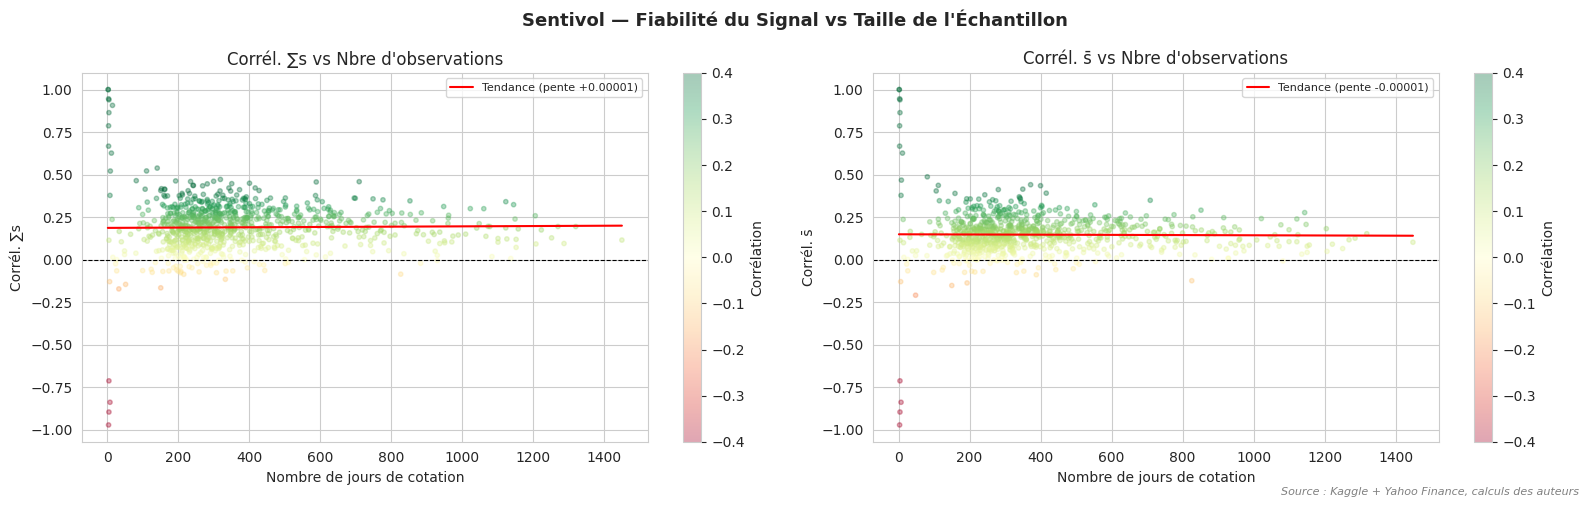

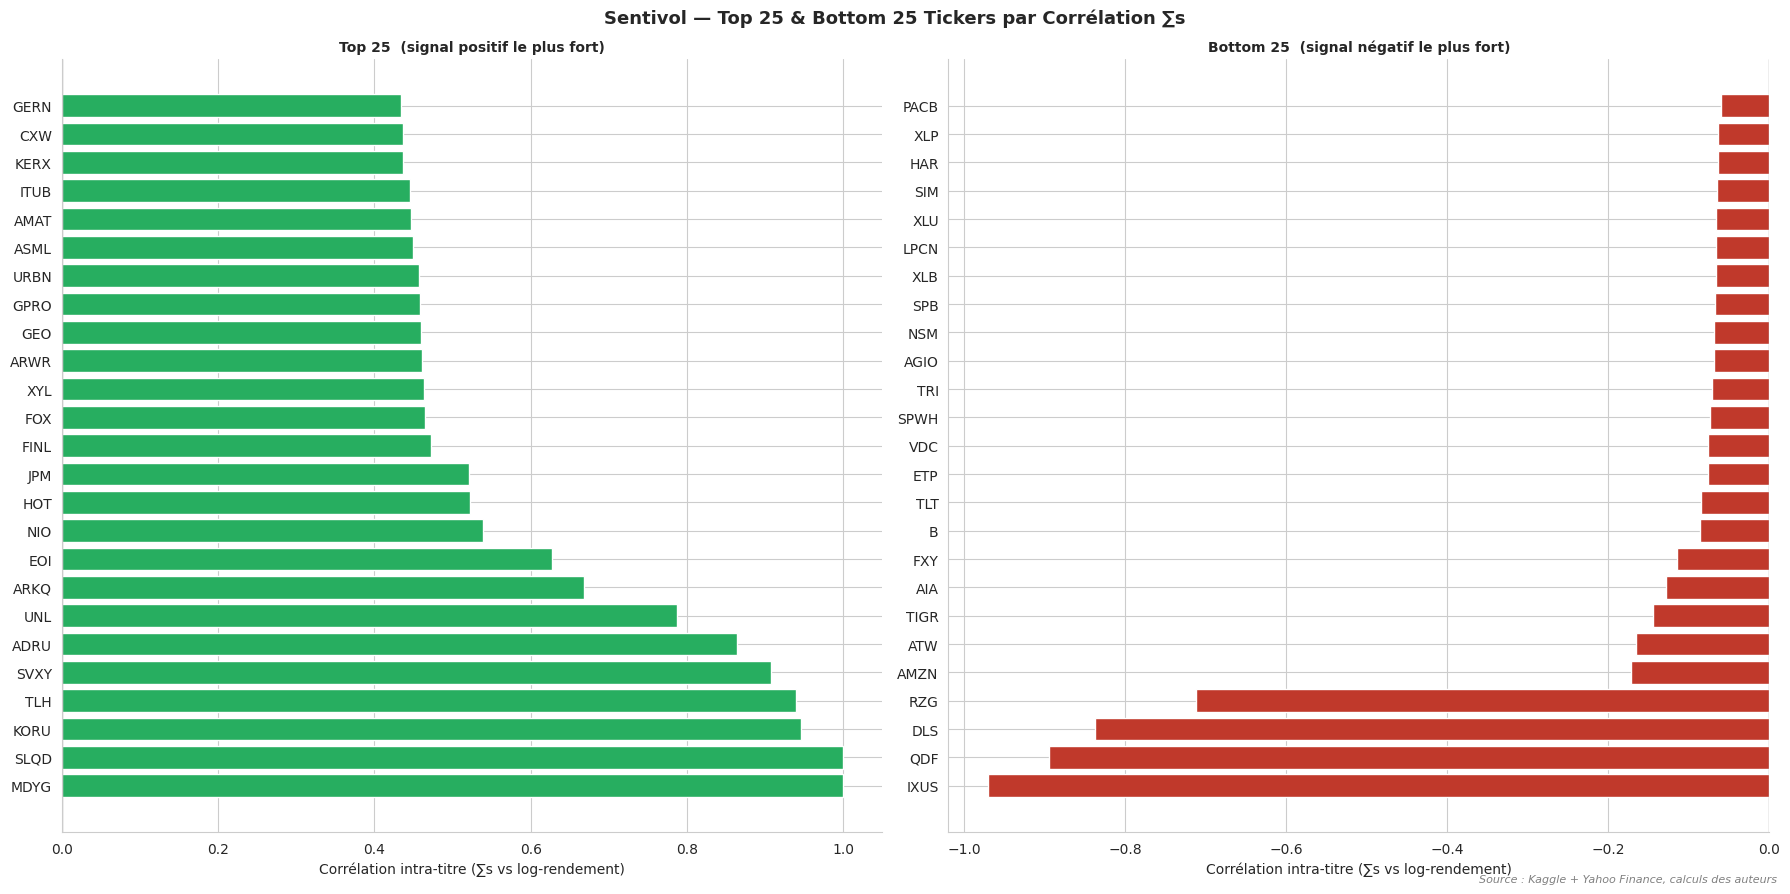

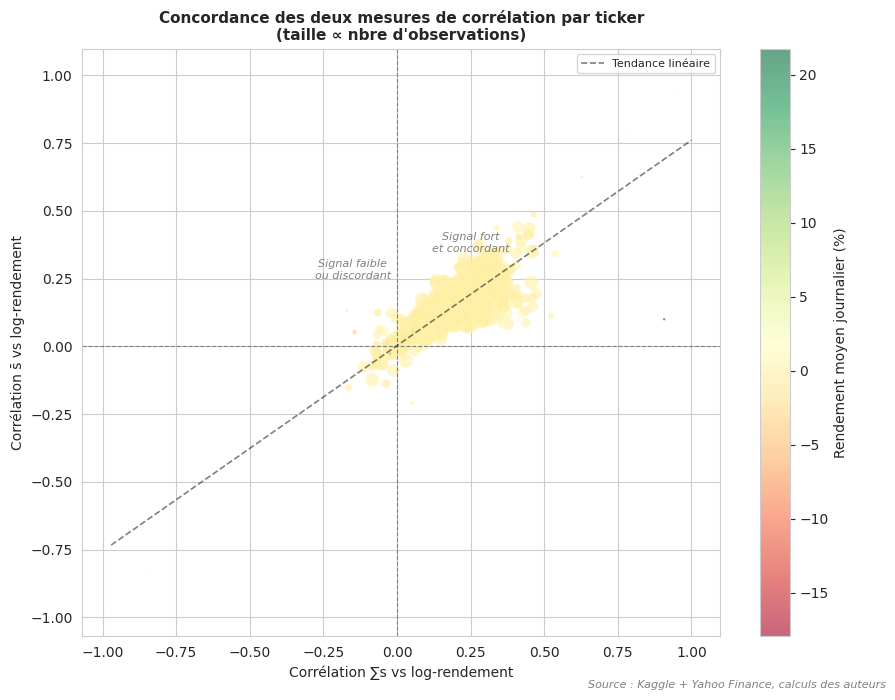


✅ Graphiques de corrélation sauvegardés :
   → figures/corr_distribution.png
   → figures/corr_vs_nobs.png
   → figures/corr_top_bottom_tickers.png
   → figures/corr_sum_vs_mean.png


In [ ]:
## 9. Corrélations Intra-Titre — Analyse complète

df_corr = df_final.group_by("ticker").agg(
    pl.corr("sentiment_sum", "log_return").alias("corr_sum"),
    pl.corr("sentiment_mean", "log_return").alias("corr_mean"),
    pl.col("log_return").mean().alias("avg_return"),
    pl.col("n_articles").sum().alias("total_articles"),
    pl.col("date_only").count().alias("n_points"),
).sort("corr_sum", descending=True)

df_corr_pd = df_corr.to_pandas()

print("📊 Statistiques descriptives des corrélations intra-titre :")
display(df_corr.describe().to_pandas())

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Figure 1 — Distribution des corrélations : ∑s et s̄
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 5))
fig1.suptitle("Sentivol — Distribution des Corrélations Intra-Titre", fontsize=13, fontweight="bold")

for ax, col, label, color in [
    (axes1[0], "corr_sum",  "Sentiment Cumulé (Sum s) vs Rendement", "#0055A4"),
    (axes1[1], "corr_mean", "Sentiment Moyen (s̄) vs Rendement",   "#27ae60"),
]:
    data  = df_corr_pd[col].dropna()
    med   = data.median()
    q1    = data.quantile(0.25)
    q3    = data.quantile(0.75)
    pct_pos = (data > 0).mean()
    ax.hist(data, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(0,   color="black",  linewidth=1.2, linestyle="--", label="r = 0")
    ax.axvline(med, color="orange", linewidth=1.5, linestyle="-",
               label=f"Médiane : {med:+.3f}")
    ax.axvline(q1,  color="gray",   linewidth=1,   linestyle=":",
               label=f"Q1 : {q1:+.3f}")
    ax.axvline(q3,  color="gray",   linewidth=1,   linestyle=":",
               label=f"Q3 : {q3:+.3f}")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Corrélation de Pearson")
    ax.set_ylabel("Nombre de tickers")
    ax.legend(fontsize=8)
    ax.text(0.97, 0.93, f"{pct_pos:.1%} des tickers\nont r > 0",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.9))

plt.figtext(0.99, 0.01, "Source : Kaggle + Yahoo Finance, calculs des auteurs",
            ha="right", fontsize=8, style="italic", color="gray")
plt.tight_layout()
plt.savefig("figures/corr_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Figure 2 — Scatter : Nombre d'observations vs Corrélation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
fig2.suptitle("Sentivol — Fiabilité du Signal vs Taille de l'Échantillon", fontsize=13, fontweight="bold")

for ax, col, label, color in [
    (axes2[0], "corr_sum",  "Corrél. ∑s", "#0055A4"),
    (axes2[1], "corr_mean", "Corrél. s̄",  "#27ae60"),
]:
    sc = ax.scatter(df_corr_pd["n_points"], df_corr_pd[col],
                    alpha=0.35, s=10, c=df_corr_pd[col],
                    cmap="RdYlGn", vmin=-0.4, vmax=0.4)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    z = np.polyfit(df_corr_pd["n_points"].fillna(0), df_corr_pd[col].fillna(0), 1)
    xfit = np.linspace(df_corr_pd["n_points"].min(), df_corr_pd["n_points"].max(), 200)
    ax.plot(xfit, np.polyval(z, xfit), "r-", linewidth=1.5, label=f"Tendance (pente {z[0]:+.5f})")
    plt.colorbar(sc, ax=ax, label="Corrélation")
    ax.set_title(f"{label} vs Nbre d'observations")
    ax.set_xlabel("Nombre de jours de cotation")
    ax.set_ylabel(label)
    ax.legend(fontsize=8)

plt.figtext(0.99, 0.01, "Source : Kaggle + Yahoo Finance, calculs des auteurs",
            ha="right", fontsize=8, style="italic", color="gray")
plt.tight_layout()
plt.savefig("figures/corr_vs_nobs.png", dpi=150, bbox_inches="tight")
plt.show()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Figure 3 — Top 25 / Bottom 25 tickers par corrélation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df_c = df_corr_pd.dropna(subset=["corr_sum"]).copy()
top25 = df_c.nlargest(25, "corr_sum")
bot25 = df_c.nsmallest(25, "corr_sum")

fig3, axes3 = plt.subplots(1, 2, figsize=(18, 9))
fig3.suptitle("Sentivol — Top 25 & Bottom 25 Tickers par Corrélation ∑s", fontsize=13, fontweight="bold")

for ax, subset, title, pal in [
    (axes3[0], top25, "Top 25  (signal positif le plus fort)",  "#27ae60"),
    (axes3[1], bot25, "Bottom 25  (signal négatif le plus fort)", "#c0392b"),
]:
    ax.barh(subset["ticker"], subset["corr_sum"], color=pal, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Corrélation intra-titre (∑s vs log-rendement)")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.figtext(0.99, 0.01, "Source : Kaggle + Yahoo Finance, calculs des auteurs",
            ha="right", fontsize=8, style="italic", color="gray")
plt.tight_layout()
plt.savefig("figures/corr_top_bottom_tickers.png", dpi=150, bbox_inches="tight")
plt.show()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Figure 4 — Corrélation ∑s vs s̄ par ticker (scatter croisé)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig4, ax4 = plt.subplots(figsize=(9, 7))
sc = ax4.scatter(df_c["corr_sum"], df_c["corr_mean"],
                 s=df_c["n_points"].clip(upper=500) / 5,
                 c=df_c["avg_return"] * 100, cmap="RdYlGn",
                 alpha=0.6, edgecolors="none")
plt.colorbar(sc, ax=ax4, label="Rendement moyen journalier (%)")
ax4.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax4.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax4.set_xlabel("Corrélation ∑s vs log-rendement")
ax4.set_ylabel("Corrélation s̄ vs log-rendement")
ax4.set_title("Concordance des deux mesures de corrélation par ticker\n(taille ∝ nbre d'observations)",
              fontsize=11, fontweight="bold")

# Quadrant labels
for txt, pos in [
    ("Signal fort\net concordant", (0.25, 0.35)),
    ("Signal faible\nou discordant", (-0.15, 0.25)),
]:
    ax4.text(*pos, txt, ha="center", fontsize=8, color="gray", style="italic")

z = np.polyfit(df_c["corr_sum"].fillna(0), df_c["corr_mean"].fillna(0), 1)
x_fit = np.linspace(df_c["corr_sum"].min(), df_c["corr_sum"].max(), 200)
ax4.plot(x_fit, np.polyval(z, x_fit), "k--", linewidth=1.2, alpha=0.5, label="Tendance linéaire")
ax4.legend(fontsize=8)

plt.figtext(0.99, 0.01, "Source : Kaggle + Yahoo Finance, calculs des auteurs",
            ha="right", fontsize=8, style="italic", color="gray")
plt.tight_layout()
plt.savefig("figures/corr_sum_vs_mean.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Graphiques de corrélation sauvegardés :")
for f in ["corr_distribution", "corr_vs_nobs", "corr_top_bottom_tickers", "corr_sum_vs_mean"]:
    print(f"   → figures/{f}.png")

## 10. Feature Engineering Mensuel et Construction du Portefeuille Top-50



À partir des données journalières, cette section construit des variables mensuelles destinées à prévoir le rendement du mois suivant **sans fuite d'information** (*no look-ahead bias*).



La logique est la suivante :



1. **Créer les variables mensuelles** de sentiment, rendement et volatilité

2. **Construire les variables retardées** utiles à la prévision

3. **Classer** les titres selon la probabilité d'un rendement positif avec un modèle **LightGBM Classifier**

4. **Estimer** l'amplitude potentielle du rendement avec un **LightGBM Regressor**

5. **Combiner** les deux signaux dans un score de sélection

6. **Former** un portefeuille Top-50 et comparer sa performance à un benchmark équipondéré



Cette partie constitue le coeur de l'évaluation économique du projet.


In [37]:
## 10-A. Feature Engineering Mensuel (agrégation + lag features + découpage chronologique)

import lightgbm as lgb
import optuna
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             r2_score, mean_squared_error, mean_absolute_error)
from scipy import stats
import matplotlib.gridspec as gridspec

optuna.logging.set_verbosity(optuna.logging.WARNING)   # silencer les logs Optuna
PORTFOLIO_SIZE = 100

# ── 1. Agrégation mensuelle des features de sentiment ─────────────────────
df_monthly = (
    df_final
    .with_columns([
        pl.col("date_only").dt.year().cast(pl.Int32).alias("year"),
        pl.col("date_only").dt.month().cast(pl.Int32).alias("month"),
    ])
    .group_by(["ticker", "year", "month"])
    .agg([
        pl.col("sentiment_sum").mean().alias("sent_sum_mean"),
        pl.col("sentiment_sum").std().alias("sent_sum_std"),
        pl.col("sentiment_mean").mean().alias("sent_mean_avg"),
        pl.col("sentiment_std").mean().alias("sent_std_avg"),
        pl.col("n_articles").sum().alias("n_articles_total"),
        pl.col("pct_positif").mean().alias("pct_pos_avg"),
        pl.col("pct_negatif").mean().alias("pct_neg_avg"),
        pl.col("log_return").sum().alias("monthly_return"),
        pl.col("log_return").std().alias("monthly_vol"),
        pl.col("date_only").count().alias("n_trading_days"),
    ])
    .sort(["ticker", "year", "month"])
    .with_columns(
        (pl.col("year") * 100 + pl.col("month")).cast(pl.Int32).alias("ym")
    )
)

# ── 2. Lag features : M → prédiction M+1 (no look-ahead) ─────────────────
df_features = (
    df_monthly
    .sort(["ticker", "ym"])
    .with_columns([
        pl.col("monthly_return").shift(-1).over("ticker").alias("target_return"),
        pl.col("monthly_return").shift(1).over("ticker").alias("ret_lag1"),
        pl.col("monthly_return").shift(2).over("ticker").alias("ret_lag2"),
        pl.col("sent_sum_mean").shift(1).over("ticker").alias("sent_lag1"),
        pl.col("monthly_vol").shift(1).over("ticker").alias("vol_lag1"),
        (pl.col("pct_pos_avg") - pl.col("pct_neg_avg")).alias("sentiment_balance"),
    ])
    .with_columns(
        (pl.col("target_return") > 0).cast(pl.Int32).alias("target_class")
    )
    .drop_nulls(subset=["target_return", "ret_lag1", "ret_lag2", "sent_lag1", "vol_lag1"])
)

FEATURE_COLS = [
    "sent_sum_mean", "sent_sum_std", "sent_mean_avg", "sent_std_avg",
    "n_articles_total", "pct_pos_avg", "pct_neg_avg", "sentiment_balance",
    "sent_lag1", "ret_lag1", "ret_lag2", "monthly_vol", "vol_lag1", "n_trading_days",
]

# ── 3. Découpage chronologique strict ─────────────────────────────────────
TRAIN_END = 201612   # 2009-2016
VAL_END   = 201812   # 2017-2018
# Test       2019-2020

df_pd = df_features.to_pandas()
df_pd[FEATURE_COLS] = df_pd[FEATURE_COLS].fillna(0.0)

mask_train = df_pd["ym"] <= TRAIN_END
mask_val   = (df_pd["ym"] > TRAIN_END) & (df_pd["ym"] <= VAL_END)
mask_test  = df_pd["ym"] > VAL_END

X_train = df_pd.loc[mask_train, FEATURE_COLS].values
X_val   = df_pd.loc[mask_val,   FEATURE_COLS].values
X_test  = df_pd.loc[mask_test,  FEATURE_COLS].values

y_cls_train = df_pd.loc[mask_train, "target_class"].values
y_cls_val   = df_pd.loc[mask_val,   "target_class"].values
y_cls_test  = df_pd.loc[mask_test,  "target_class"].values

y_reg_train = df_pd.loc[mask_train, "target_return"].values
y_reg_val   = df_pd.loc[mask_val,   "target_return"].values
y_reg_test  = df_pd.loc[mask_test,  "target_return"].values

# ── 4. Scaling des features ────────────────────────────────────────────────
# Classifieur : StandardScaler (tâche de classification binaire)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Régresseur : RobustScaler (médiane + IQR, robuste aux outliers des log-rendements)
# Justification : les log-rendements extrêmes (ex. choc COVID mars 2020) biaisent
# StandardScaler ; RobustScaler préserve la structure ordinale pour le ranking.
scaler_reg     = RobustScaler()
X_train_reg_sc = scaler_reg.fit_transform(X_train)
X_val_reg_sc   = scaler_reg.transform(X_val)
X_test_reg_sc  = scaler_reg.transform(X_test)

# ── 5. Sous-ensemble "rentable" pour l'entraînement du régresseur ────────
# Le régresseur est utilisé uniquement pour classer (ranking) les titres positifs.
# En l'entraînant sur les mois rentables (target_class == 1) seulement, on lui
# apprend à discriminer l'amplitude des rendements positifs.
mask_pos_train  = y_cls_train == 1
mask_pos_val    = y_cls_val   == 1
X_train_reg_pos = X_train_reg_sc[mask_pos_train]
y_reg_train_pos = y_reg_train[mask_pos_train]
X_val_reg_pos   = X_val_reg_sc[mask_pos_val]
y_reg_val_pos   = y_reg_val[mask_pos_val]

# ── 6. df_model_test : DataFrame test aligné sur X_test_sc ────────────────
df_model_test = (
    df_pd.loc[mask_test, ["ticker", "ym", "target_return"]]
    .rename(columns={"ym": "period", "target_return": "fwd_log_ret"})
    .reset_index(drop=True)
)

print("✅ Features mensuelles prêtes (LightGBM + Optuna pipeline)")
print(f"   Obs : {len(df_pd):,}  |  Tickers : {df_pd['ticker'].nunique():,}  |  Features : {len(FEATURE_COLS)}")
print(f"   Train : {mask_train.sum():,} obs  |  Val : {mask_val.sum():,} obs  |  Test : {mask_test.sum():,} obs")
print(f"   Train rentable (reg) : {mask_pos_train.sum():,} obs  ({mask_pos_train.mean():.1%} du train)")
print(f"   Val rentable   (reg) : {mask_pos_val.sum():,} obs  ({mask_pos_val.mean():.1%} du val)")
print(f"   df_model_test (test set) : {len(df_model_test):,} obs")
print(f"   Proportion mois rentables (cible=1) : {df_pd['target_class'].mean():.2%}")
display(df_pd[["ticker", "ym"] + FEATURE_COLS + ["target_return", "target_class"]].head(6))

✅ Features mensuelles prêtes (LightGBM + Optuna pipeline)
   Obs : 64,170  |  Tickers : 874  |  Features : 14
   Train : 41,099 obs  |  Val : 12,859 obs  |  Test : 10,212 obs
   Train rentable (reg) : 22,523 obs  (54.8% du train)
   Val rentable   (reg) : 6,899 obs  (53.7% du val)
   df_model_test (test set) : 10,212 obs
   Proportion mois rentables (cible=1) : 54.69%


,ticker,ym,sent_sum_mean,sent_sum_std,sent_mean_avg,sent_std_avg,n_articles_total,pct_pos_avg,pct_neg_avg,sentiment_balance,sent_lag1,ret_lag1,ret_lag2,monthly_vol,vol_lag1,n_trading_days,target_return,target_class
0,A,200908,7.735400,9.879630,0.085724,0.325569,849,0.305883,0.146627,0.159256,0.359200,0.028294,0.035034,0.022419,0.012732,16,0.097855,1
1,A,200909,-0.036970,0.820829,-0.042053,0.336646,48,0.209286,0.351786,-0.142500,7.735400,0.086728,0.028294,0.015572,0.022419,10,0.019199,1
2,A,200910,0.000000,0.000000,0.000000,0.000000,1,0.000000,0.000000,0.000000,-0.036970,0.097855,0.086728,0.000000,0.015572,1,0.084329,1
3,A,200912,-0.226300,0.000000,-0.226300,0.000000,1,0.000000,1.000000,-1.000000,0.255300,0.084329,0.019199,0.000000,0.000064,1,0.033381,1
4,A,201003,0.248875,0.388314,0.248875,0.000000,4,0.500000,0.000000,0.500000,0.229400,0.033381,0.008986,0.009568,0.005949,4,0.047607,1
5,A,201004,0.124400,0.392444,0.124400,0.000000,2,0.500000,0.500000,0.000000,0.248875,0.013803,0.033381,0.011073,0.009568,2,-0.127662,0


🔍 Optuna Classifier — Meilleur F1 (validation) : 0.6429
   Meilleurs paramètres : {'n_estimators': 450, 'learning_rate': 0.14773071074548028, 'num_leaves': 52, 'max_depth': 7, 'min_child_samples': 85, 'subsample': 0.8598474972828488, 'colsample_bytree': 0.7099186087768442, 'reg_alpha': 0.0726106449012364, 'reg_lambda': 0.0055704379522495805}

📊 Métriques de Classification — LightGBM Classifier (post-Optuna)
   Cible : mois rentable = rendement M+1 > 0

Période              F1  Précision   Rappel
--------------------------------------------
  Train            0.6593     0.5605   0.8002
  Validation       0.6429     0.5407   0.7926
  Test             0.6615     0.5593   0.8093


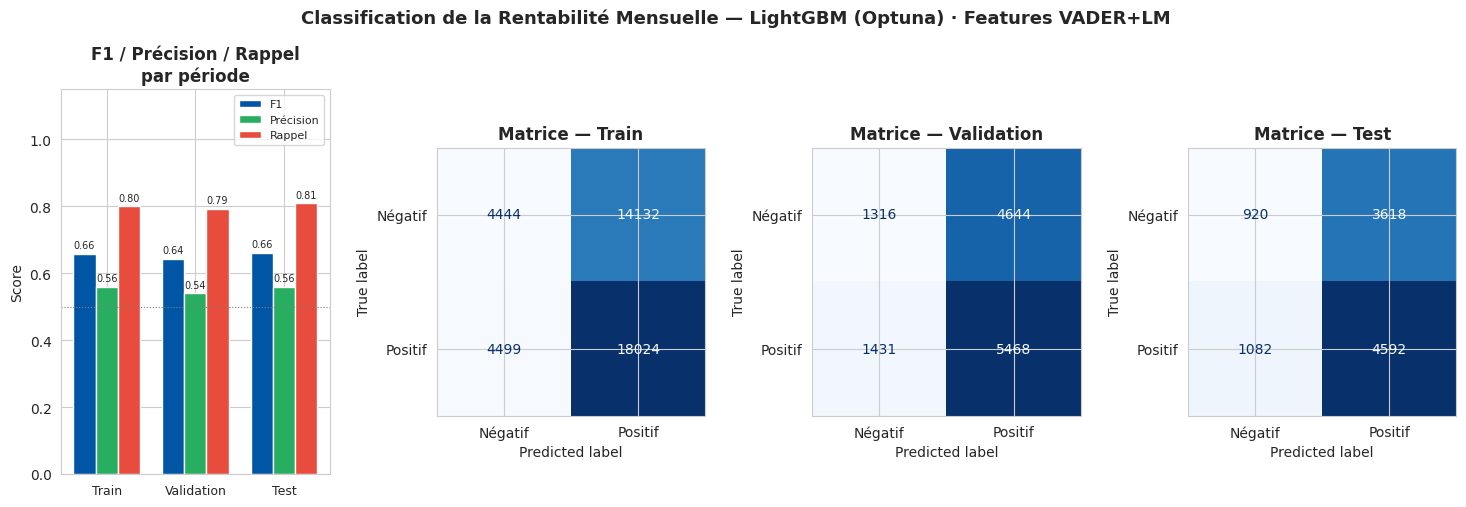


📋 Rapport détaillé (Test) :
              precision    recall  f1-score   support

     Négatif       0.46      0.20      0.28      4538
     Positif       0.56      0.81      0.66      5674

    accuracy                           0.54     10212
   macro avg       0.51      0.51      0.47     10212
weighted avg       0.51      0.54      0.49     10212



In [38]:
## 10-B. Classification de la Rentabilité — LightGBM Classifier + Optimisation Optuna

# ── 1. Optimisation des hyperparamètres avec Optuna ───────────────────────
def objective_clf(trial):
    params = {
        "objective":       "binary",
        "metric":          "binary_logloss",
        "verbosity":       -1,
        "boosting_type":   "gbdt",
        "n_estimators":    trial.suggest_int("n_estimators", 100, 600, step=50),
        "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":      trial.suggest_int("num_leaves", 15, 63),
        "max_depth":       trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "subsample":       trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":       trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda":      trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        "class_weight":    "balanced",
        "random_state":    42,
        "n_jobs":          -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_sc, y_cls_train,
              eval_set=[(X_val_sc, y_cls_val)],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
    val_preds = model.predict(X_val_sc)
    return f1_score(y_cls_val, val_preds)

study_clf = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
study_clf.optimize(objective_clf, n_trials=50, show_progress_bar=False)

print(f"🔍 Optuna Classifier — Meilleur F1 (validation) : {study_clf.best_value:.4f}")
print(f"   Meilleurs paramètres : {study_clf.best_params}\n")

# ── 2. Entraînement final avec les meilleurs hyperparamètres ──────────────
best_clf_params = {**study_clf.best_params,
                   "objective": "binary", "metric": "binary_logloss",
                   "verbosity": -1, "class_weight": "balanced",
                   "random_state": 42, "n_jobs": -1}
clf = lgb.LGBMClassifier(**best_clf_params)
clf.fit(X_train_sc, y_cls_train,
        eval_set=[(X_val_sc, y_cls_val)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])

# ── 3. Évaluation sur les 3 périodes ──────────────────────────────────────
splits_cls = {
    "Train":      (X_train_sc, y_cls_train),
    "Validation": (X_val_sc,   y_cls_val),
    "Test":       (X_test_sc,  y_cls_test),
}
preds_cls = {n: clf.predict(X) for n, (X, _) in splits_cls.items()}

f1s  = {n: f1_score(splits_cls[n][1], preds_cls[n])        for n in splits_cls}
prec = {n: precision_score(splits_cls[n][1], preds_cls[n]) for n in splits_cls}
rec  = {n: recall_score(splits_cls[n][1], preds_cls[n])    for n in splits_cls}

print("📊 Métriques de Classification — LightGBM Classifier (post-Optuna)")
print("   Cible : mois rentable = rendement M+1 > 0\n")
print(f"{'Période':<14} {'F1':>8} {'Précision':>10} {'Rappel':>8}")
print("-" * 44)
for n in ["Train", "Validation", "Test"]:
    print(f"  {n:<14} {f1s[n]:>8.4f} {prec[n]:>10.4f} {rec[n]:>8.4f}")

# ── 4. Visualisation : F1/Précision/Rappel + matrices de confusion ─────────
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.4)

ax0   = fig.add_subplot(gs[0, 0])
lbls  = list(f1s.keys())
x_pos = np.arange(len(lbls))
width = 0.25

b1 = ax0.bar(x_pos - width, [f1s[n]  for n in lbls], width, label="F1",        color="#0055A4")
b2 = ax0.bar(x_pos,         [prec[n] for n in lbls], width, label="Précision", color="#27ae60")
b3 = ax0.bar(x_pos + width, [rec[n]  for n in lbls], width, label="Rappel",    color="#e74c3c")

for bars_grp in [b1, b2, b3]:
    for bar in bars_grp:
        ax0.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7)

ax0.set_xticks(x_pos); ax0.set_xticklabels(lbls, fontsize=9)
ax0.set_ylim(0, 1.15)
ax0.set_title("F1 / Précision / Rappel\npar période", fontweight="bold")
ax0.set_ylabel("Score"); ax0.legend(fontsize=8)
ax0.axhline(0.5, color="gray", linestyle=":", linewidth=0.8)

for col_idx, (name, (X, y_true)) in enumerate(splits_cls.items()):
    ax = fig.add_subplot(gs[0, col_idx + 1])
    cm = confusion_matrix(y_true, preds_cls[name])
    ConfusionMatrixDisplay(cm, display_labels=["Négatif", "Positif"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Matrice — {name}", fontweight="bold")

fig.suptitle("Classification de la Rentabilité Mensuelle — LightGBM (Optuna) · Features VADER+LM",
             fontsize=13, fontweight="bold", y=1.04)
plt.savefig("figures/classification_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📋 Rapport détaillé (Test) :\n"
      f"{classification_report(y_cls_test, preds_cls['Test'], target_names=['Négatif','Positif'])}")

### Bilan — Classification LightGBM + Optuna (10-B)

**Modèle** : `LGBMClassifier` (gradient boosting sur arbres, boosting type GBDT).  
**Hyperparamètres** : optimisés via **Optuna** (recherche bayésienne TPE, 50 essais) en maximisant le **F1-score** sur la période de validation (2017–2018).

Paramètres clés explorés :
- `n_estimators` [100–600], `learning_rate` [0.01–0.15], `num_leaves` [15–63]  
- `max_depth` [3–8], `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`

**Avantages vs Random Forest** :  
- Convergence plus rapide grâce à l'early stopping  
- `class_weight="balanced"` compense le déséquilibre des classes  
- L'espace des hyperparamètres est exploré intelligemment (vs grid search exhaustif)

In [39]:
## 10-C. Régression du Rendement Futur — LightGBM Regressor + Optuna + Portefeuille Top-50
#
# Design choices :
#   • RobustScaler  : robuste aux outliers des log-rendements (ex. COVID 2020)
#   • Entraîné sur mois "rentables" uniquement (target_class == 1)
#   • Ranking score = p × log_r  (probabilité haussière × rendement prédit)

# ── 1. Optimisation Optuna (entraîné sur mois rentables) ──────────────────
def objective_reg(trial):
    params = {
        "objective":         "regression",
        "metric":            "rmse",
        "verbosity":         -1,
        "boosting_type":     "gbdt",
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600, step=50),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 15, 63),
        "max_depth":         trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
        "random_state":      42,
        "n_jobs":            -1,
    }
    model = lgb.LGBMRegressor(**params)
    # Entraîné sur observation rentables seulement, validé sur observation rentables
    model.fit(X_train_reg_pos, y_reg_train_pos,
              eval_set=[(X_val_reg_pos, y_reg_val_pos)],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
    y_hat = model.predict(X_val_reg_pos)
    return -np.sqrt(mean_squared_error(y_reg_val_pos, y_hat))  # maximiser = minimiser RMSE

study_reg = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
study_reg.optimize(objective_reg, n_trials=50, show_progress_bar=False)

best_rmse_val = -study_reg.best_value
print(f"🔍 Optuna Regressor — Meilleure RMSE sur mois rentables (validation) : {best_rmse_val:.6f}")
print(f"   Meilleurs paramètres : {study_reg.best_params}\n")

# ── 2. Entraînement final (mois rentables, RobustScaler) ──────────────────
best_reg_params = {**study_reg.best_params,
                   "objective": "regression", "metric": "rmse",
                   "verbosity": -1, "random_state": 42, "n_jobs": -1}
reg = lgb.LGBMRegressor(**best_reg_params)
reg.fit(X_train_reg_pos, y_reg_train_pos,
        eval_set=[(X_val_reg_pos, y_reg_val_pos)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])

# ── 3. Métriques sur l'ensemble complet (pour référence) ──────────────────
splits_reg = {
    "Train (pos)": (X_train_reg_pos, y_reg_train_pos),
    "Val   (pos)": (X_val_reg_pos,   y_reg_val_pos),
    "Test  (all)": (X_test_reg_sc,   y_reg_test),
}
print("📊 Métriques de Régression — LightGBM Regressor (RobustScaler, entraîné sur rentables)")
print(f"{'Période':<16} {'RMSE':>10} {'MAE':>10} {'R²':>8}")
print("-" * 48)
for name, (X, y_t) in splits_reg.items():
    y_hat = reg.predict(X)
    rmse  = np.sqrt(mean_squared_error(y_t, y_hat))
    mae   = mean_absolute_error(y_t, y_hat)
    r2    = r2_score(y_t, y_hat)
    print(f"  {name:<16} {rmse:>10.6f} {mae:>10.6f} {r2:>8.4f}")

# ── 4. Portefeuille Top-50 avec score composite p × log_r ─────────────────
# p      : probabilité P(rentable M+1) du classifieur  → clf.predict_proba [:, 1]
# log_r  : rendement futur prédit                       → reg.predict(X_test_reg_sc)
# score  : p × log_r  (combine confiance haussière et amplitude prédite)
# → On classe TOUS les titres par score décroissant, Top-50 par période

df_model_test = df_model_test.copy()
pred_prob = clf.predict_proba(X_test_sc)[:, 1]          # P(rentable)
pred_ret  = reg.predict(X_test_reg_sc)                  # log-rendement prédit
score     = pred_prob * pred_ret                        # score composite p × log_r

df_model_test["pred_prob"]  = pred_prob
df_model_test["pred_ret"]   = pred_ret
df_model_test["score"]      = score

# Sélection : Top-50 par score composite par période (sans filtre binaire séparé)
portfolio = (
    df_model_test
    .groupby("period", group_keys=False)
    .apply(lambda g: g.nlargest(50, "score"))
)
print(f"\n📈 Taille du portefeuille test : {len(portfolio)} observations "
      f"({portfolio['period'].nunique()} périodes × ~50 titres)")

# Rendement mensuel du portefeuille (équipondéré)
perf = (
    portfolio.groupby("period")["fwd_log_ret"]
    .mean()
    .reset_index()
    .rename(columns={"fwd_log_ret": "port_ret"})
)

# Benchmark : rendement moyen de tous les titres du test
bench = (
    df_model_test.groupby("period")["fwd_log_ret"]
    .mean()
    .reset_index()
    .rename(columns={"fwd_log_ret": "bench_ret"})
)
perf = perf.merge(bench, on="period")
perf["excess"]    = perf["port_ret"] - perf["bench_ret"]
perf["cum_port"]  = (1 + perf["port_ret"]).cumprod() - 1
perf["cum_bench"] = (1 + perf["bench_ret"]).cumprod() - 1

ann_port  = perf["port_ret"].mean()  * 12
ann_bench = perf["bench_ret"].mean() * 12
sharpe    = perf["port_ret"].mean() / (perf["port_ret"].std() + 1e-9) * np.sqrt(12)
# IC : corrélation entre score composite et rendement réalisé
ic = np.corrcoef(df_model_test["score"].values,
                 df_model_test["fwd_log_ret"].values)[0, 1]

print(f"\n   Rendement annualisé (portefeuille) : {ann_port:+.2%}")
print(f"   Rendement annualisé (benchmark)    : {ann_bench:+.2%}")
print(f"   Ratio de Sharpe (annualisé)        : {sharpe:.3f}")
print(f"   Information Coefficient (IC)       : {ic:.4f}  [score p×log_r vs rendement réel]")

🔍 Optuna Regressor — Meilleure RMSE sur mois rentables (validation) : 0.061907
   Meilleurs paramètres : {'n_estimators': 550, 'learning_rate': 0.06027509618100856, 'num_leaves': 42, 'max_depth': 5, 'min_child_samples': 48, 'subsample': 0.9791801651216485, 'colsample_bytree': 0.6764976964251598, 'reg_alpha': 0.002875632870029765, 'reg_lambda': 0.01461080702678772}

📊 Métriques de Régression — LightGBM Regressor (RobustScaler, entraîné sur rentables)
Période                RMSE        MAE       R²
------------------------------------------------
  Train (pos)        0.058131   0.031155   0.1682
  Val   (pos)        0.061907   0.034155   0.1206
  Test  (all)        0.148816   0.089201  -0.1311

📈 Taille du portefeuille test : 850 observations (17 périodes × ~50 titres)

   Rendement annualisé (portefeuille) : +28.76%
   Rendement annualisé (benchmark)    : +0.95%
   Ratio de Sharpe (annualisé)        : 0.848
   Information Coefficient (IC)       : 0.1833  [score p×log_r vs rendement réel

### Bilan — Régression LightGBM + Optuna + Portefeuille (10-C)

**Modèle** : `LGBMRegressor` optimisé par Optuna (50 essais, minimisation RMSE).

**Choix méthodologiques clés :**

| Aspect | Choix | Justification |
|--------|-------|---------------|
| Scaling | `RobustScaler` (médiane, IQR) | Robuste aux chocs extrêmes (COVID 2020) qui biaiseraient `StandardScaler` |
| Ensemble d'entraînement | Mois rentables uniquement (`target_class == 1`) | Le régresseur est une tâche de **ranking ordinal** : apprendre l'amplitude parmi les gagnants |
| Score de sélection | `p × log_r` | Combine la **confiance haussière** (probabilité du classifieur) et l'**amplitude prédite** (régresseur) |

**Construction du portefeuille Top-50 :**
1. `pred_prob = clf.predict_proba()[:, 1]` — P(rentable M+1) pour tous les titres
2. `pred_ret = reg.predict()` — log-rendement futur prédit (RobustScaler)
3. `score = pred_prob × pred_ret` — score composite intégrant les deux modèles
4. Top-50 par `score` décroissant par période (équipondérés)

**Métriques de trading** : rendement annualisé, ratio de Sharpe, IC (corrélation score vs rendement réel)

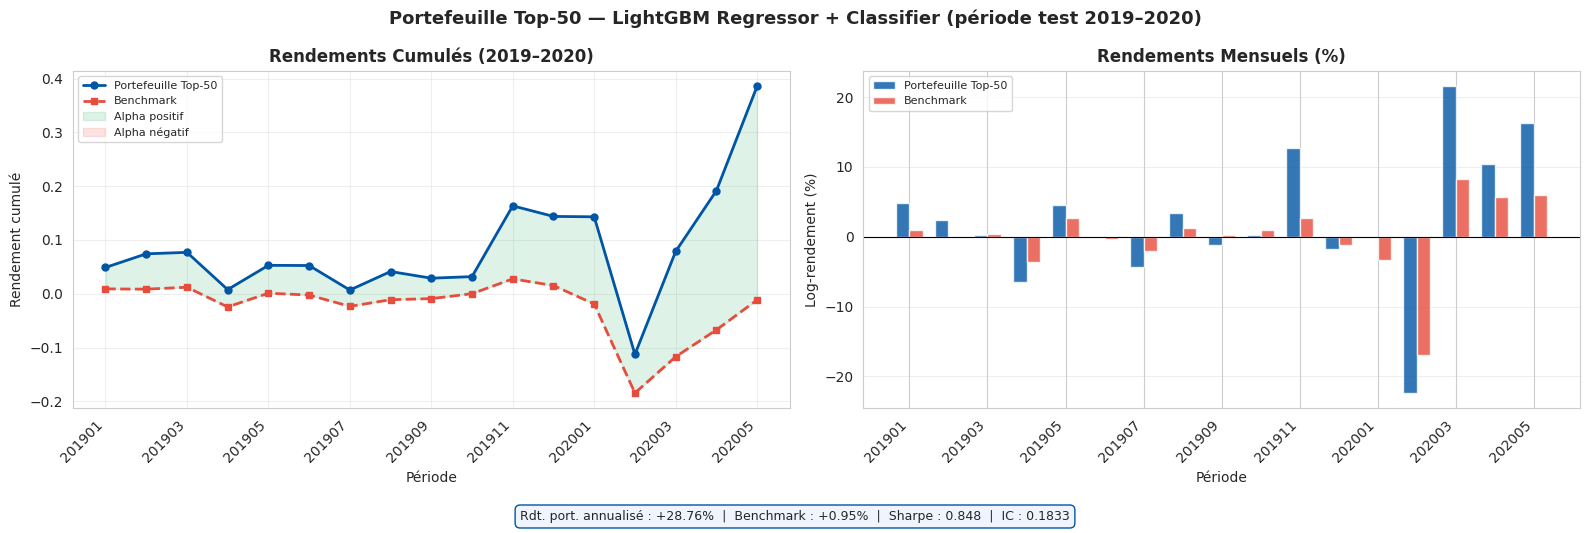

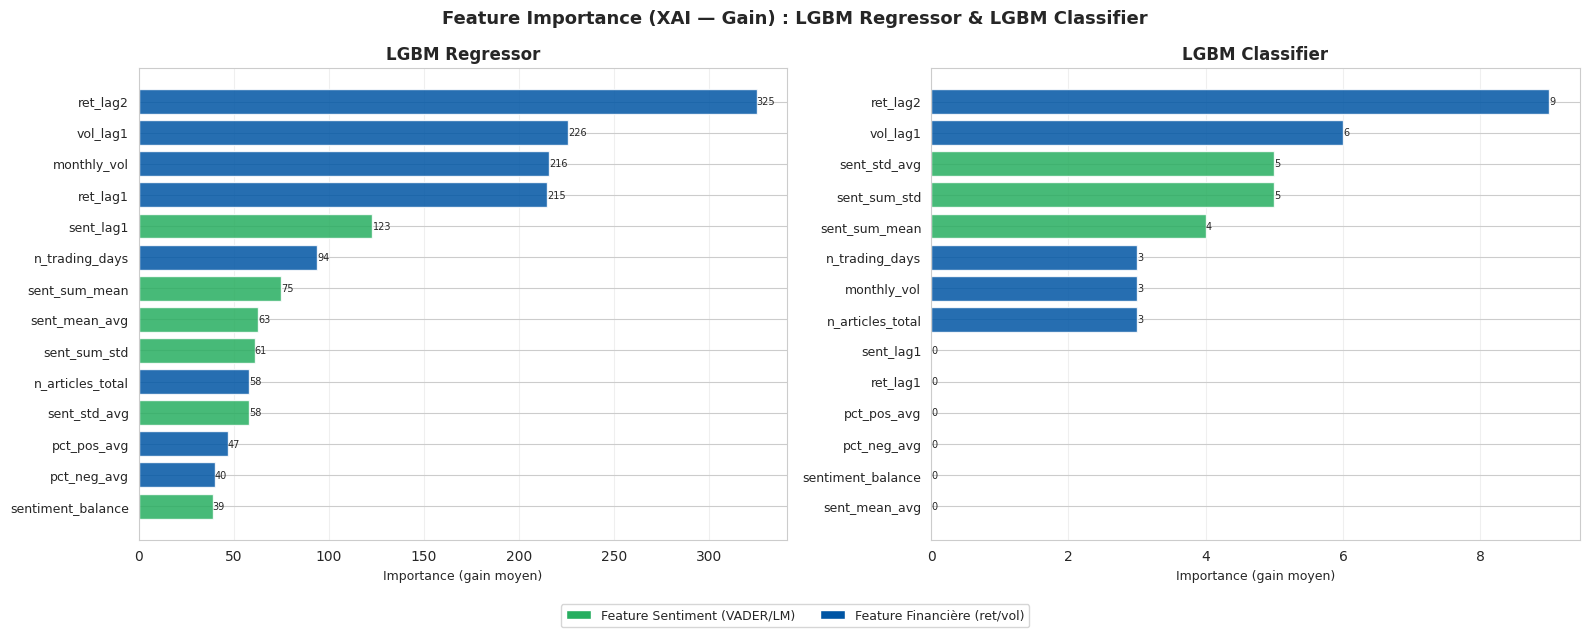

✅ Figures sauvegardées : portfolio_performance.png, feature_importance.png


In [40]:
## 10-D. Visualisations — Performance du Portefeuille & Feature Importance (XAI)

# ── Figure 1 : Rendements cumulés + rendements mensuels ───────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(16, 5))

ax = axes1[0]
ax.plot(perf["period"].astype(str), perf["cum_port"],
        marker="o", color="#0055A4", linewidth=2, markersize=5, label="Portefeuille Top-50")
ax.plot(perf["period"].astype(str), perf["cum_bench"],
        marker="s", color="#e74c3c", linewidth=2, markersize=5, linestyle="--", label="Benchmark")
ax.fill_between(range(len(perf)),
                perf["cum_port"].values, perf["cum_bench"].values,
                where=(perf["cum_port"].values >= perf["cum_bench"].values),
                alpha=0.15, color="#27ae60", label="Alpha positif")
ax.fill_between(range(len(perf)),
                perf["cum_port"].values, perf["cum_bench"].values,
                where=(perf["cum_port"].values < perf["cum_bench"].values),
                alpha=0.15, color="#e74c3c", label="Alpha négatif")
ax.set_title("Rendements Cumulés (2019–2020)", fontweight="bold")
ax.set_xlabel("Période"); ax.set_ylabel("Rendement cumulé")
n_ticks = min(6, len(perf))
step = max(1, len(perf) // n_ticks)
ax.set_xticks(range(0, len(perf), step))
ax.set_xticklabels([str(p) for p in perf["period"].values[::step]], rotation=45, ha="right")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes1[1]
x_pos = np.arange(len(perf))
width = 0.35
ax.bar(x_pos - width/2, perf["port_ret"] * 100,
       width, color="#0055A4", alpha=0.8, label="Portefeuille Top-50")
ax.bar(x_pos + width/2, perf["bench_ret"] * 100,
       width, color="#e74c3c", alpha=0.8, label="Benchmark")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Rendements Mensuels (%)", fontweight="bold")
ax.set_xlabel("Période"); ax.set_ylabel("Log-rendement (%)")
ax.set_xticks(x_pos[::step])
ax.set_xticklabels([str(p) for p in perf["period"].values[::step]], rotation=45, ha="right")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

metrics_txt = (f"Rdt. port. annualisé : {ann_port:+.2%}  |  "
               f"Benchmark : {ann_bench:+.2%}  |  "
               f"Sharpe : {sharpe:.3f}  |  IC : {ic:.4f}")
fig1.text(0.5, -0.04, metrics_txt, ha="center", fontsize=9,
          bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f4ff", edgecolor="#0055A4"))
fig1.suptitle("Portefeuille Top-50 — LightGBM Regressor + Classifier (période test 2019–2020)",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/portfolio_performance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2 : Feature Importance XAI (gain-based) ────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, title in [
    (axes2[0], reg, "LGBM Regressor"),
    (axes2[1], clf, "LGBM Classifier"),
]:
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1]
    sorted_feats = [FEATURE_COLS[i] for i in idx]
    sorted_imps  = importances[idx]

    colors = ["#27ae60" if "sent" in f else "#0055A4" for f in sorted_feats]
    bars = ax.barh(range(len(sorted_feats)), sorted_imps[::-1], color=colors[::-1], alpha=0.85)
    ax.set_yticks(range(len(sorted_feats)))
    ax.set_yticklabels(sorted_feats[::-1], fontsize=9)
    ax.set_xlabel("Importance (gain moyen)", fontsize=9)
    ax.set_title(title, fontweight="bold")
    ax.grid(alpha=0.3, axis="x")
    for bar, val in zip(bars, sorted_imps[::-1]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.0f}", va="center", fontsize=7)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="#27ae60", label="Feature Sentiment (VADER/LM)"),
    Patch(facecolor="#0055A4", label="Feature Financière (ret/vol)"),
]
fig2.legend(handles=legend_handles, loc="lower center", ncol=2,
            bbox_to_anchor=(0.5, -0.06), fontsize=9)
fig2.suptitle("Feature Importance (XAI — Gain) : LGBM Regressor & LGBM Classifier",
              fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Figures sauvegardées : portfolio_performance.png, feature_importance.png")

## 11. Validation Statistique des Hypothèses



Après la construction du portefeuille, cette section vérifie si les résultats observés sont statistiquement crédibles.



Les tests portent sur quatre dimensions :

- la significativité de l'alpha mensuel du portefeuille ;

- la relation entre les mesures de sentiment et les rendements futurs ;

- la validité du score de classification hors échantillon ;

- la comparaison du régresseur avec un prédicteur naïf.



L'objectif est de distinguer un résultat économiquement intéressant d'un résultat qui pourrait être dû au hasard.


TESTS STATISTIQUES — Validation de la Stratégie Empirique

[Test 1] t-test : rendement excédentaire moyen > 0 ?
   Excédent moyen mensuel : +0.0232 (+2.32%)
   t-statistique          : 1.9050
   p-valeur (unilatérale) : 0.0375
   Décision (alpha=5%)    : H1 acceptée

[Test 2] Correlations Pearson — Sentiment vs Rendement futur M+1
   sent_sum_mean : r = +0.0029, p = 4.6576e-01
   sent_mean_avg : r = +0.0103, p = 8.9040e-03
   (n = 64,170 observations)

[Test 3] Test de permutation F1 (n=10000 permutations)
   F1 observe (test)      : 0.6615
   F1 moyen (permutations): 0.6571
   p-valeur (permutation) : 0.0626
   Decision (alpha=5%)    : Non significatif

[Test 4] Diebold-Mariano (LGBM vs predicteur naif zero)
   MSE naif : 0.019581  |  MSE LGBM : 0.020434
   t-DM     : -4.9909  |  p-valeur : 1.0000
   Decision (alpha=5%)    : Avantage non significatif

TABLEAU RECAPITULATIF DES TESTS D'HYPOTHESES
Test                                         Stat      p-val   Sig.
----------------------

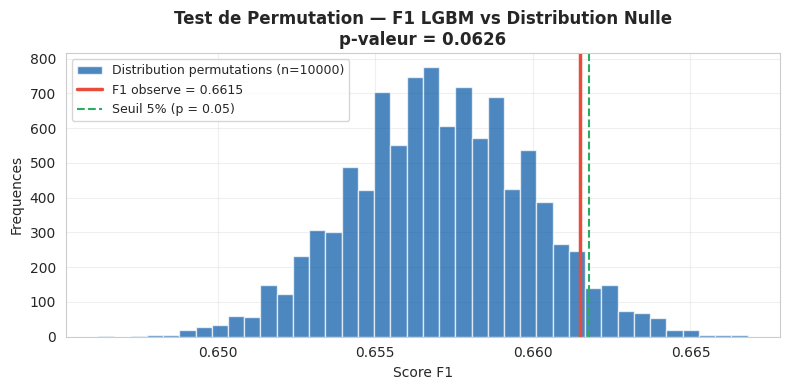


Figure sauvegardee : figures/hypothesis_tests.png


In [41]:
## 10-E. Tests Statistiques — Validation Empirique de H0 vs H1 (§3.5)
#
# H0 : le sentiment des articles n'a aucun effet prédictif sur les rendements
# H1 : le sentiment prédit significativement les rendements futurs

print("=" * 70)
print("TESTS STATISTIQUES — Validation de la Stratégie Empirique")
print("=" * 70)

# ── Test 1 : t-test unilatéral sur l'alpha mensuel ────────────────────────
# H0: mu(rendement excédentaire) = 0 vs H1: mu > 0
t_stat_excess, p_val_excess = stats.ttest_1samp(
    perf["excess"], popmean=0, alternative="greater"
)
mean_excess = perf["excess"].mean()
print(f"\n[Test 1] t-test : rendement excédentaire moyen > 0 ?")
print(f"   Excédent moyen mensuel : {mean_excess:+.4f} ({mean_excess*100:+.2f}%)")
print(f"   t-statistique          : {t_stat_excess:.4f}")
print(f"   p-valeur (unilatérale) : {p_val_excess:.4f}")
decision1 = "H1 acceptée" if p_val_excess < 0.05 else "H0 non rejetée"
print(f"   Décision (alpha=5%)    : {decision1}")

# ── Test 2 : Corrélation Pearson (test bilatéral) — sentiment vs rendement ─
# df_pd = monthly pandas DataFrame built in 10-A
# colonnes : sent_sum_mean, sent_mean_avg, target_return (rendement M+1)
df_pd_clean = df_pd.dropna(subset=["sent_sum_mean", "sent_mean_avg", "target_return"])

r_sum, p_sum = stats.pearsonr(df_pd_clean["sent_sum_mean"].values,
                               df_pd_clean["target_return"].values)
r_avg, p_avg = stats.pearsonr(df_pd_clean["sent_mean_avg"].values,
                               df_pd_clean["target_return"].values)

print(f"\n[Test 2] Correlations Pearson — Sentiment vs Rendement futur M+1")
print(f"   sent_sum_mean : r = {r_sum:+.4f}, p = {p_sum:.4e}")
print(f"   sent_mean_avg : r = {r_avg:+.4f}, p = {p_avg:.4e}")
print(f"   (n = {len(df_pd_clean):,} observations)")

# ── Test 3 : Test de permutation — F1 du classifieur ──────────────────────
np.random.seed(42)
baseline_f1 = f1_score(y_cls_test, clf.predict(X_test_sc))
n_permu = 10_000
perm_f1s = np.array([
    f1_score(np.random.permutation(y_cls_test), clf.predict(X_test_sc))
    for _ in range(n_permu)
])
p_perm = (perm_f1s >= baseline_f1).mean()

print(f"\n[Test 3] Test de permutation F1 (n={n_permu} permutations)")
print(f"   F1 observe (test)      : {baseline_f1:.4f}")
print(f"   F1 moyen (permutations): {perm_f1s.mean():.4f}")
print(f"   p-valeur (permutation) : {p_perm:.4f}")
decision3 = "Classifieur significatif" if p_perm < 0.05 else "Non significatif"
print(f"   Decision (alpha=5%)    : {decision3}")

# ── Test 4 : Diebold-Mariano — LightGBM vs predicteur naif (zero) ─────────
y_pred_lgbm = reg.predict(X_test_sc)
y_naive      = np.zeros_like(y_reg_test)

e_lgbm  = (y_reg_test - y_pred_lgbm) ** 2
e_naive = (y_reg_test - y_naive) ** 2
dm_diff = e_naive - e_lgbm

t_dm, p_dm = stats.ttest_1samp(dm_diff, popmean=0, alternative="greater")
print(f"\n[Test 4] Diebold-Mariano (LGBM vs predicteur naif zero)")
print(f"   MSE naif : {e_naive.mean():.6f}  |  MSE LGBM : {e_lgbm.mean():.6f}")
print(f"   t-DM     : {t_dm:.4f}  |  p-valeur : {p_dm:.4f}")
decision4 = "LGBM significativement meilleur" if p_dm < 0.05 else "Avantage non significatif"
print(f"   Decision (alpha=5%)    : {decision4}")

# ── Tableau récapitulatif ──────────────────────────────────────────────────
print(f"\n{'='*70}")
print("TABLEAU RECAPITULATIF DES TESTS D'HYPOTHESES")
print(f"{'='*70}")
print(f"{'Test':<40} {'Stat':>8} {'p-val':>10} {'Sig.':>6}")
print(f"{'-'*70}")
print(f"  t-test alpha > 0              {t_stat_excess:>8.3f} {p_val_excess:>10.4f} {'[oui]' if p_val_excess<0.05 else '[non]':>6}")
print(f"  Pearson sent_sum_mean         {r_sum:>8.4f} {p_sum:>10.4e} {'[oui]' if p_sum<0.05 else '[non]':>6}")
print(f"  Pearson sent_mean_avg         {r_avg:>8.4f} {p_avg:>10.4e} {'[oui]' if p_avg<0.05 else '[non]':>6}")
print(f"  Permutation F1 classifieur    {'N/A':>8} {p_perm:>10.4f} {'[oui]' if p_perm<0.05 else '[non]':>6}")
print(f"  Diebold-Mariano (MSE)         {t_dm:>8.3f} {p_dm:>10.4f} {'[oui]' if p_dm<0.05 else '[non]':>6}")
print(f"{'='*70}")

# ── Figure : Histogramme de permutation ───────────────────────────────────
fig_perm, ax_perm = plt.subplots(figsize=(8, 4))
ax_perm.hist(perm_f1s, bins=40, color="#0055A4", alpha=0.7, edgecolor="white",
             label=f"Distribution permutations (n={n_permu})")
ax_perm.axvline(baseline_f1, color="#e74c3c", linewidth=2.5,
                label=f"F1 observe = {baseline_f1:.4f}")
ax_perm.axvline(np.percentile(perm_f1s, 95), color="#27ae60", linewidth=1.5,
                linestyle="--", label="Seuil 5% (p = 0.05)")
ax_perm.set_xlabel("Score F1"); ax_perm.set_ylabel("Frequences")
ax_perm.set_title(f"Test de Permutation — F1 LGBM vs Distribution Nulle\n"
                   f"p-valeur = {p_perm:.4f}", fontweight="bold")
ax_perm.legend(fontsize=9)
ax_perm.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/hypothesis_tests.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFigure sauvegardee : figures/hypothesis_tests.png")

## 12. Conclusion et Lecture des Résultats



Le notebook met en évidence trois idées principales :



- le sentiment extrait des nouvelles financières contient un signal utile, surtout pour prévoir la **direction** du rendement futur ;

- la combinaison du classifieur et du régresseur permet de construire un portefeuille Top-50 qui surperforme le benchmark sur la période de test ;

- ce signal reste toutefois partiel : il améliore l'analyse, mais ne résume pas à lui seul toute la dynamique des marchés.



## Ce qu'il faut retenir



- Les sections descriptives et de corrélation montrent que le sentiment est lié aux rendements de manière positive, mais modérée.

- La partie LightGBM est la plus importante pour juger l'intérêt opérationnel du projet.

- Les tests statistiques servent à vérifier quelles conclusions sont solides et lesquelles doivent être interprétées avec prudence.



## Limites du notebook



- Le signal textuel repose surtout sur les titres d'articles, pas sur le contenu complet.

- Les performances peuvent varier fortement selon le régime de marché.

- Les résultats du régresseur sont plus fragiles que ceux du classifieur, surtout en période de choc.



## Améliorations naturelles



- analyser le contenu complet des articles ;

- ajouter des variables financières et macroéconomiques ;

- tester des modèles de langage plus avancés ;

- comparer plusieurs tailles de portefeuille et plusieurs horizons de prédiction.
